<a href="https://colab.research.google.com/github/Luma-Chen/MachineLearning/blob/main/Brent_Oil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import random
import time
import itertools
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

#Dataset

In [ ]:
def download_brent_dataset():
    tickers = {
        "Brent_Oil": "BZ=F",      # Petróleo Brent (Alvo)
        "Natural_Gas": "NG=F",    # Gás Natural
        "Dollar_Index": "DX-Y.NYB", # Índice do Dólar (DXY)
        "Gold": "GC=F",           # Ouro (Refúgio seguro)
        "SP500": "^GSPC",         # Índice S&P 500 (Saúde da economia)
        "EURUSD": "EURUSD=X",     # Câmbio Euro/Dólar
        "Volatility_VIX": "^VIX", # Índice do Medo (Risco de mercado)
        "Nasdaq": "^IXIC",        # NASDAQ Composite (Setor tecnológico e crescimento)
        "FedFunds_Proxy": "^IRX", # Taxa de Juros (3-Month Treasury Bill - o melhor proxy diário do Fed)
        "US_Inflation_Proxy": "TIP", # Inflação (iShares TIPS Bond ETF - reflete a expectativa diária de inflação)
        "Emerging_Markets": "EEM", # Mercados Emergentes (iShares MSCI Emerging Markets ETF)
        "Gasoline_RBOB": "RB=F"   # Gasolina Futuros (Indicador de demanda de refino/consumo)
    }

    print("Iniciando download dos dados...")
    data= yf.download(list(tickers.values()), start="2014-01-01", end="2025-12-31")['Close']

    #Renomear colunas para nomes legíveis
    #Invertemos o dicionário para mapear ticker -> nome
    inv_tickers= {v: k for k, v in tickers.items()}
    data= data.rename(columns=inv_tickers)

    #Tratamento de Dados
    df_clean= data.ffill() #propaga os últimos preços válidos para cobrir feriados desencontrados
    df_clean = df_clean.dropna()

    print(f"Download concluído! Matriz gerada: {df_clean.shape[0]} linhas x {df_clean.shape[1]} colunas.")
    return df_clean

In [ ]:
dataset= download_brent_dataset ()
dataset.to_csv ("brent_data_study.csv")

print ("Arquivo 'brent_data_study.csv' salvo com sucesso!")
print (dataset)

Iniciando download dos dados...


/tmp/ipykernel_21859/1365037946.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data= yf.download(list(tickers.values()), start="2014-01-01", end="2025-12-31")['Close']
[*********************100%***********************]  12 of 12 completed

Download concluído! Matriz gerada: 3126 linhas x 12 colunas.
Arquivo 'brent_data_study.csv' salvo com sucesso!
Ticker       Brent_Oil  Dollar_Index  Emerging_Markets    EURUSD         Gold  \
Date                                                                            
2014-01-02  107.779999     80.629997         30.618050  1.376671  1225.000000   
2014-01-03  106.889999     80.790001         30.564726  1.366662  1238.400024   
2014-01-06  106.730003     80.650002         30.275229  1.359601  1237.800049   
2014-01-07  107.349998     80.830002         30.404739  1.363196  1229.400024   
2014-01-08  107.150002     81.040001         30.305702  1.361637  1225.300049   
...                ...           ...               ...       ...          ...   
2025-12-23   62.380001     97.940002         54.029171  1.176595  4482.799805   
2025-12-24   62.240002     97.980003         54.138599  1.179551  4480.600098   
2025-12-26   60.639999     98.019997         54.516636  1.178536  4529.100098  

#NAIVE - Random Walk


Iniciando o Naive (Random Walk) para o ano de Validação (2024)...

================ RESULTADOS NAIVE (VALIDAÇÃO 2024) ================
MAE em 2024: $0.9579
RMSE em 2024: $1.2832
MAPE em 2024: 1.2141%

Iniciando o Naive (Random Walk) para o ano de Teste (2025)...

================ RESULTADOS NAIVE (TESTE 2025) ================
MAE em 2025: $0.8984
RMSE em 2025: $1.2356
MAPE em 2025: 1.3189%


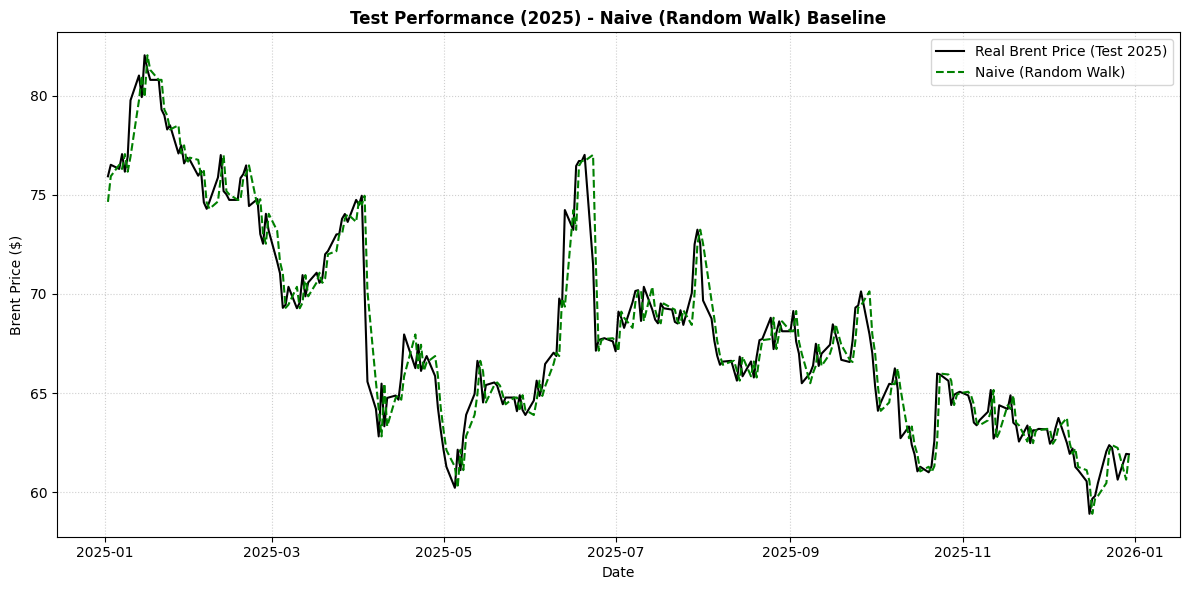

In [ ]:
print("\nIniciando o Naive (Random Walk) para o ano de Validação (2024)...")

train_brent = dataset.loc["2014-01-01":"2023-12-31", "Brent_Oil"]
val_brent   = dataset.loc["2024-01-01":"2024-12-31", "Brent_Oil"]
test_brent  = dataset.loc["2025-01-01":"2025-12-31", "Brent_Oil"]

brent_train = train_brent.values
brent_val   = val_brent.values
brent_test  = test_brent.values

naive_pred_val = np.empty(len(brent_val))
naive_pred_val[0] = brent_train[-1]
naive_pred_val[1:] = brent_val[:-1]

mae_naive_val  = mean_absolute_error(brent_val, naive_pred_val)
rmse_naive_val = np.sqrt(mean_squared_error(brent_val, naive_pred_val))
mape_naive_val = mean_absolute_percentage_error(brent_val, naive_pred_val) * 100

print("\n================ RESULTADOS NAIVE (VALIDAÇÃO 2024) ================")
print(f"MAE em 2024: ${mae_naive_val:.4f}")
print(f"RMSE em 2024: ${rmse_naive_val:.4f}")
print(f"MAPE em 2024: {mape_naive_val:.4f}%")

print("\nIniciando o Naive (Random Walk) para o ano de Teste (2025)...")

naive_pred_test = np.empty(len(brent_test))
naive_pred_test[0] = brent_val[-1]
naive_pred_test[1:] = brent_test[:-1]

mae_naive_test  = mean_absolute_error(brent_test, naive_pred_test)
rmse_naive_test = np.sqrt(mean_squared_error(brent_test, naive_pred_test))
mape_naive_test = mean_absolute_percentage_error(brent_test, naive_pred_test) * 100

print("\n================ RESULTADOS NAIVE (TESTE 2025) ================")
print(f"MAE em 2025: ${mae_naive_test:.4f}")
print(f"RMSE em 2025: ${rmse_naive_test:.4f}")
print(f"MAPE em 2025: {mape_naive_test:.4f}%")

datas_teste = test_brent.index

plt.figure(figsize=(12, 6))
plt.plot(datas_teste, brent_test, label="Real Brent Price (Test 2025)", color="black", linewidth=1.5)
plt.plot(datas_teste, naive_pred_test, label="Naive (Random Walk)", color="green", linestyle="--", linewidth=1.5)
plt.title("Test Performance (2025) - Naive (Random Walk) Baseline", fontsize=12, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Brent Price ($)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

#ARIMA Forecasting

##ARIMA Validation Set

Iniciando o Rolling Forecast adaptativo para os 262 dias de mercado de 2024...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'



================ RESULTADOS ARIMA (VALIDAÇÃO OTIMIZADA 2024) ================
MAE em 2024: $0.96
RMSE em 2024: $1.28
MAPE em 2024: 1.21%
Tempo Total de Validação: 198.3573 segundos
Tempo Médio por Predição Diária: 0.757089 segundos (262 dias úteis)


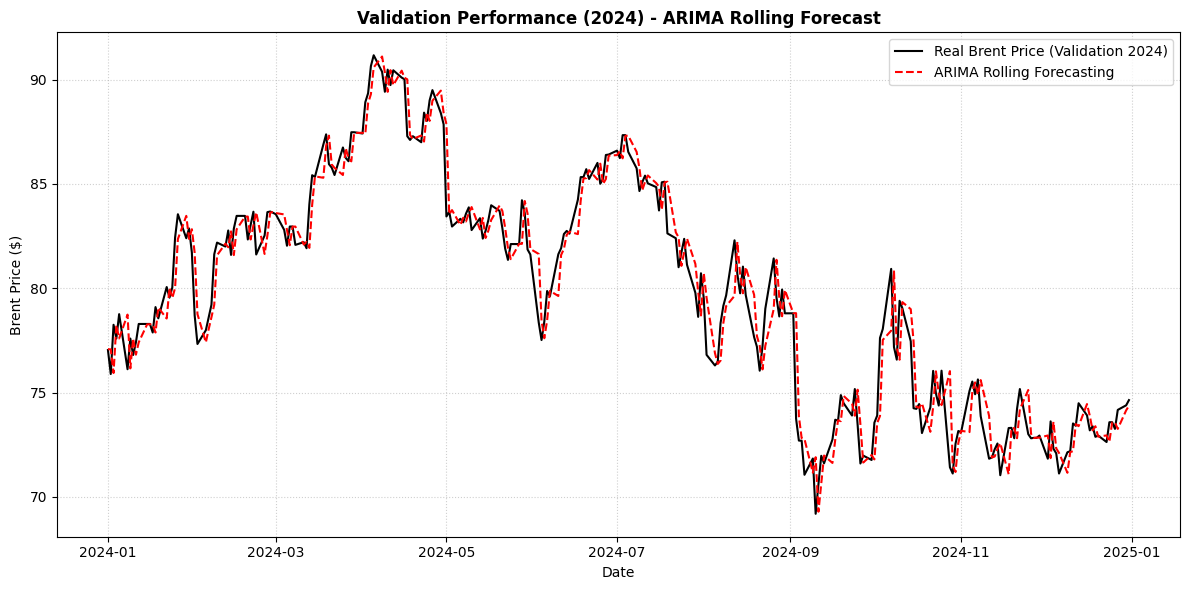

In [ ]:
train_brent= dataset.loc["2014-01-01":"2023-12-31", "Brent_Oil"]
val_brent= dataset.loc["2024-01-01":"2024-12-31", "Brent_Oil"]

print(f"Iniciando o Rolling Forecast adaptativo para os {len(val_brent)} dias de mercado de 2024...")

tempo_inicio_val= time.time()
history= list(train_brent)
rolling_predictions_val= []

#p= lags autorregressivos | d= diferenciações para estabilidade | q= janelas de média móvel
p, d, q = 1, 1, 1

#O Loop de Previsão Diária (Rolling Forecast)
#O laço percorre o tamanho do vetor de validação (val_brent)
for time_point in range(len(val_brent)):
    #Ajusta o modelo ARIMA com todo o histórico acumulado até aquele dia específico
    model= ARIMA(history, order= (p, d, q))
    model_fitted= model.fit()

    #Projeta rigorosamente APENAS 1 passo à frente (o preço do dia seguinte)
    output= model_fitted.forecast(steps=1)
    yhat= output[0]
    rolling_predictions_val.append(yhat)

    #Captura o valor REAL de validação e adiciona na memória para o próximo passo
    actual_value= val_brent.iloc[time_point]
    history.append(actual_value)

tempo_fim_val= time.time()
tempo_total_val= tempo_fim_val - tempo_inicio_val
tempo_medio_diario_val= tempo_total_val / len(val_brent)

#Transforma a lista final de previsões em uma Série com o índice de 2024
predictions_series_val= pd.Series(rolling_predictions_val, index=val_brent.index)

mae_arima_val= mean_absolute_error(val_brent, predictions_series_val)
rmse_arima_val= np.sqrt(mean_squared_error(val_brent, predictions_series_val))
mape_arima_val= mean_absolute_percentage_error(val_brent, predictions_series_val) * 100
print("\n================ RESULTADOS ARIMA (VALIDAÇÃO OTIMIZADA 2024) ================")
print(f"MAE em 2024: ${mae_arima_val:.2f}")
print(f"RMSE em 2024: ${rmse_arima_val:.2f}")
print(f"MAPE em 2024: {mape_arima_val:.2f}%")
print(f"Tempo Total de Validação: {tempo_total_val:.4f} segundos")
print(f"Tempo Médio por Predição Diária: {tempo_medio_diario_val:.6f} segundos ({len(val_brent)} dias úteis)")

plt.figure(figsize=(12, 6))
plt.plot(val_brent, label="Real Brent Price (Validation 2024)", color="black", linewidth=1.5)
plt.plot(predictions_series_val, label="ARIMA Rolling Forecasting", color="red", linestyle="--", linewidth=1.5)
plt.title("Validation Performance (2024) - ARIMA Rolling Forecast", fontsize=12, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Brent Price ($)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

##ARIMA Test Set

Iniciando o Rolling Forecast adaptativo para os 257 dias de mercado de 2025...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'



--- Resultado do Baseline ARIMA (Rolling Forecast) ---
MAE do ARIMA em 2025: $0.90
RMSE do ARIMA em 2025: $1.24
MAPE do ARIMA em 2025: 1.32%
Tempo Total de Teste: 222.4750 segundos
Tempo Médio por Predição Diária: 0.849141 segundos (262 dias úteis)


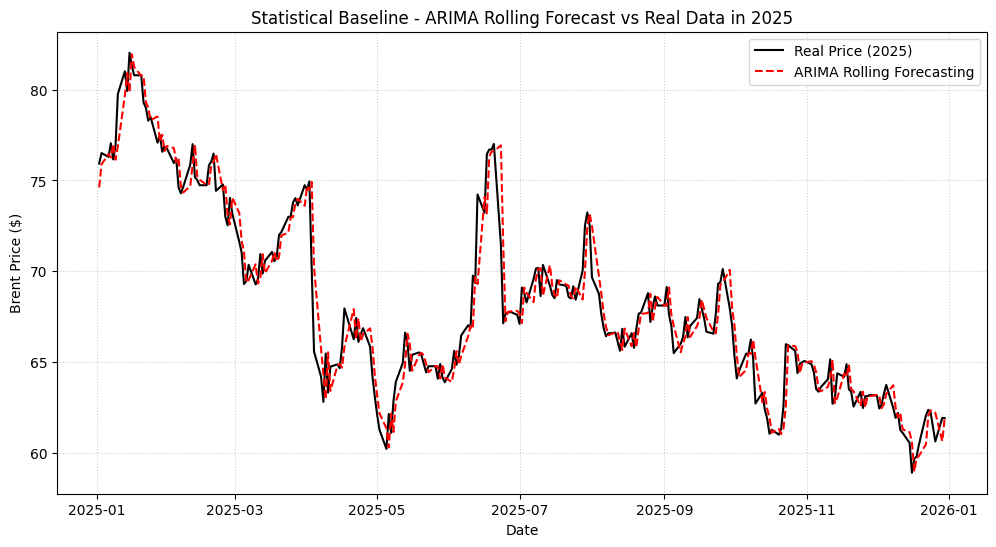

In [ ]:
train_brent= dataset.loc["2014-01-01":"2024-12-31", "Brent_Oil"]
test_brent= dataset.loc["2025-01-01":"2025-12-31", "Brent_Oil"]

print(f"Iniciando o Rolling Forecast adaptativo para os {len(test_brent)} dias de mercado de 2025...")

tempo_inicio_val= time.time()
history= list(train_brent)
rolling_predictions= []

#p= lags autorregressivos | d= diferenciações para estabilidade | q= janelas de média móvel
p, d, q = 1, 1, 1

#O Loop de Previsão Diária (Rolling Forecast)
for time_point in range(len(test_brent)):
    #Ajusta o modelo ARIMA com todo o histórico acumulado até aquele dia específico
    model= ARIMA(history, order= (p, d, q))
    model_fitted= model.fit()

    #Projeta rigorosamente APENAS 1 passo à frente (o preço do dia seguinte)
    output= model_fitted.forecast(steps=1)
    yhat= output[0]
    rolling_predictions.append(yhat)

    #Pega o valor REAL que aconteceu no dia de teste e adiciona na memória do modelo para a predição do próximo passo
    actual_value= test_brent.iloc[time_point]
    history.append(actual_value)

tempo_fim_val= time.time()
tempo_total_val= tempo_fim_val - tempo_inicio_val
tempo_medio_diario_val= tempo_total_val / len(val_brent)

#Transforma a lista final de previsões em uma Série do Pandas e injeta as datas reais de 2025
prediction_arima_rolling = pd.Series(rolling_predictions, index=test_brent.index)

#Avaliação de Desempenho Realista (Métricas baseadas no Rolling Forecast)
mae_arima= mean_absolute_error(test_brent, prediction_arima_rolling)
mape_arima= mean_absolute_percentage_error(test_brent, prediction_arima_rolling) * 100
rmse_arima= np.sqrt(mean_squared_error(test_brent, prediction_arima_rolling))

print("\n--- Resultado do Baseline ARIMA (Rolling Forecast) ---")
print(f"MAE do ARIMA em 2025: ${mae_arima:.2f}")
print(f"RMSE do ARIMA em 2025: ${rmse_arima:.2f}")
print(f"MAPE do ARIMA em 2025: {mape_arima:.2f}%")
print(f"Tempo Total de Teste: {tempo_total_val:.4f} segundos")
print(f"Tempo Médio por Predição Diária: {tempo_medio_diario_val:.6f} segundos ({len(val_brent)} dias úteis)")

#Plotagem Visual Avançada para a Dissertação
plt.figure(figsize=(12, 6))
plt.plot(test_brent, label="Real Price (2025)", color="black", linewidth=1.5)
plt.plot(prediction_arima_rolling, label="ARIMA Rolling Forecasting", color="red", linestyle="--", linewidth=1.5)
plt.title("Statistical Baseline - ARIMA Rolling Forecast vs Real Data in 2025")
plt.xlabel("Date")
plt.ylabel("Brent Price ($)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.show()

Iniciando a predição estática para os 257 dias de mercado de 2025...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using


--- Resultado do Baseline ARIMA (Previsão Estática) ---
MAE do ARIMA em 2025: $7.17
RMSE do ARIMA em 2025: $8.14
MAPE do ARIMA em 2025: 10.94%
Tempo Total de Teste: 0.9931 segundos
Tempo Médio por Predição Diária: 0.003864 segundos (257 dias úteis)


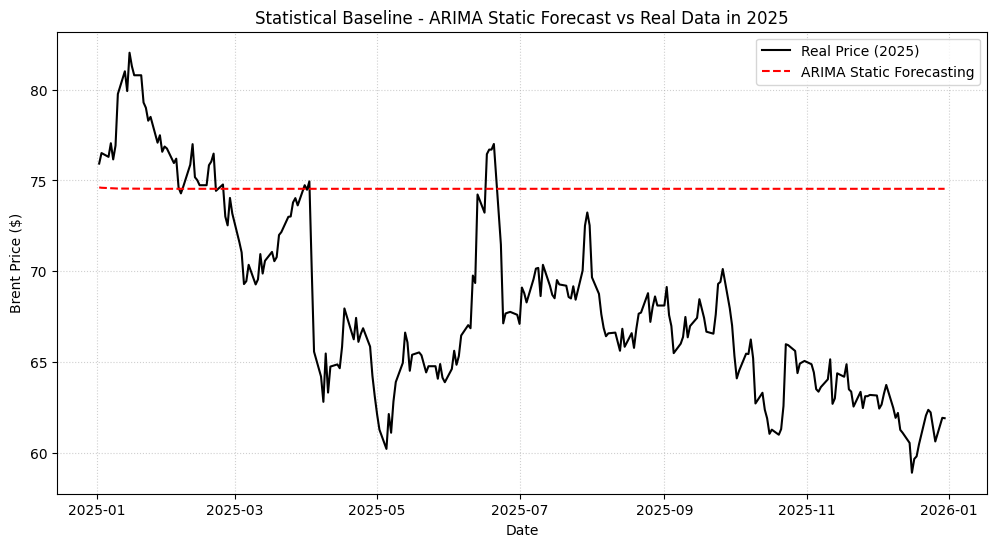

In [ ]:
train_brent= dataset.loc["2014-01-01":"2024-12-31", "Brent_Oil"]
test_brent= dataset.loc["2025-01-01":"2025-12-31", "Brent_Oil"]

print(f"Iniciando a predição estática para os {len(test_brent)} dias de mercado de 2025...")

tempo_inicio_val= time.time()

#p= lags autorregressivos | d= diferenciações para estabilidade | q= janelas de média móvel
p, d, q= 1, 1, 1

#Ajusta o modelo ARIMA uma única vez com todo o histórico de treino (2014-2024)
model= ARIMA(train_brent, order= (p, d, q))
model_fitted= model.fit()

#Projeta estaticamente TODOS os passos à frente para o ano de 2025 de uma vez só
rolling_predictions= model_fitted.forecast(steps=len(test_brent))

tempo_fim_val= time.time()
tempo_total_val= tempo_fim_val - tempo_inicio_val
tempo_medio_diario_val= tempo_total_val / len(test_brent)

#Transforma o resultado em uma Série do Pandas alinhada com o index real de 2025
prediction_arima_static= pd.Series(rolling_predictions.values, index=test_brent.index)

#Avaliação de Desempenho Realista (Métricas baseadas na Predição Estática)
mae_arima= mean_absolute_error(test_brent, prediction_arima_static)
mape_arima= mean_absolute_percentage_error(test_brent, prediction_arima_static) * 100
rmse_arima= np.sqrt(mean_squared_error(test_brent, prediction_arima_static))

print("\n--- Resultado do Baseline ARIMA (Previsão Estática) ---")
print(f"MAE do ARIMA em 2025: ${mae_arima:.2f}")
print(f"RMSE do ARIMA em 2025: ${rmse_arima:.2f}")
print(f"MAPE do ARIMA em 2025: {mape_arima:.2f}%")
print(f"Tempo Total de Teste: {tempo_total_val:.4f} segundos")
print(f"Tempo Médio por Predição Diária: {tempo_medio_diario_val:.6f} segundos ({len(test_brent)} dias úteis)")

#Plotagem Visual Avançada para a Dissertação
plt.figure(figsize=(12, 6))
plt.plot(test_brent, label="Real Price (2025)", color="black", linewidth=1.5)
plt.plot(prediction_arima_static, label="ARIMA Static Forecasting", color="red", linestyle="--", linewidth=1.5)
plt.title("Statistical Baseline - ARIMA Static Forecast vs Real Data in 2025")
plt.xlabel("Date")
plt.ylabel("Brent Price ($)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.show()

#Pre-Processing Steps

In [ ]:
#1. DIVISÃO TEMPORAL RÍGIDA (Treino: 2014-2023 | Validação: 2024 | Teste: 2025)
train_df= dataset.loc["2014-01-01":"2023-12-31"]
val_df= dataset.loc["2024-01-01":"2024-12-31"]
test_df= dataset.loc["2025-01-01":"2025-12-31"]

#2. NORMALIZAÇÃO BLINDADA (Evitando Vazamento de Dados / Data Leakage)
#O scaler aprende os parâmetros (média, min, max) APENAS com o passado estrutural (Treino)
scaler= MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_df)

#Aplica a transformação de forma isolada nos três conjuntos
train_scaled= scaler.transform(train_df)
val_scaled= scaler.transform(val_df)
test_scaled= scaler.transform(test_df)

#3. CONCATENAÇÃO DE SEGURANÇA PARA A JANELA DESLIZANTE
#Para que o primeiro dia de 2024 tenha os 10 dias de histórico de 2023 e o primeiro dia de 2025 tenha os 10 dias de histórico de 2024:
window_size= 10

val_extended= np.vstack([train_scaled[-window_size:], val_scaled])
test_extended= np.vstack([val_scaled[-window_size:], test_scaled])

#4. FUNÇÃO DE JANELA DESLIZANTE MULTIVARIADA
def create_sliding_windows(data, window_size, target_col_idx=0):
    X, y= [], []
    for i in range(len(data) - window_size):
        X.append(data[i : (i + window_size), :])  #Histórico de todas as colunas
        y.append(
            data[i + window_size, target_col_idx]
        )  #Alvo: Brent no dia seguinte
    return np.array(X), np.array(y)

#Criação das janelas usando as matrizes estendidas garantindo o tamanho total dos blocos
X_train_lstm, y_train= create_sliding_windows(train_scaled, window_size)
X_val_lstm, y_val= create_sliding_windows(val_extended, window_size)
X_test_lstm, y_test= create_sliding_windows(test_extended, window_size)

#5. ESTRUTURAÇÃO DAS DIMENSÕES (3D para LSTM e 2D para RF/SVR)
print("--- FORMATOS PARA DEEP LEARNING (LSTM) ---")
print(f"Shape Treino LSTM:     {X_train_lstm.shape}")  #(N_amostras, 10, 12)
print(f"Shape Validação LSTM:  {X_val_lstm.shape}")  #(N_amostras, 10, 12)
print(f"Shape Teste LSTM:      {X_test_lstm.shape}\n")  #(N_amostras, 10, 12)

#Achatando as duas últimas dimensões
X_train_rf= X_train_lstm.reshape(X_train_lstm.shape[0], -1)
X_val_rf= X_val_lstm.reshape(X_val_lstm.shape[0], -1)
#IMPORTANTE: X_test_rf será usado para o seu modelo campeão final em 2025
X_test_rf= X_test_lstm.reshape(X_test_lstm.shape[0], -1)

print(f"Shape Treino RF/SVR:    {X_train_rf.shape}") #(N_amostras, 120)
print(f"Shape Validação RF/SVR: {X_val_rf.shape}") #(N_amostras, 120)
print(f"Shape Teste RF/SVR:     {X_test_rf.shape}") #(N_amostras, 120)

--- FORMATOS PARA DEEP LEARNING (LSTM) ---
Shape Treino LSTM:     (2597, 10, 12)
Shape Validação LSTM:  (262, 10, 12)
Shape Teste LSTM:      (257, 10, 12)

Shape Treino RF/SVR:    (2597, 120)
Shape Validação RF/SVR: (262, 120)
Shape Teste RF/SVR:     (257, 120)


#Ridge Regression


######################################################################
RIDGE REGRESSION - COMPARAÇÃO DE FEATURES
######################################################################
Shape Ridge somente Brent: (2597, 10) (262, 10) (257, 10)
Shape Ridge todas variáveis: (2597, 120) (262, 120) (257, 120)

RIDGE - SOMENTE BRENT

VALIDAÇÃO 2024
MAE:  $1.0991
RMSE: $1.4298
MAPE: 1.3904%
Tempo de treino: 0.0056 segundos

TESTE 2025
MAE:  $1.0717
RMSE: $1.4779
MAPE: 1.5705%

RIDGE - TODAS AS VARIÁVEIS

VALIDAÇÃO 2024
MAE:  $1.0971
RMSE: $1.4113
MAPE: 1.3872%
Tempo de treino: 0.0074 segundos

TESTE 2025
MAE:  $1.0630
RMSE: $1.4575
MAPE: 1.5554%

================ COMPARAÇÃO RIDGE ================
          Modelo  MAE Val 2024  RMSE Val 2024  MAPE Val 2024  MAE Test 2025  \
0  Ridge - Brent        1.0991         1.4298         1.3904         1.0717   
1  Ridge - Todas        1.0971         1.4113         1.3872         1.0630   

   RMSE Test 2025  MAPE Test 2025  
0          1.4779          

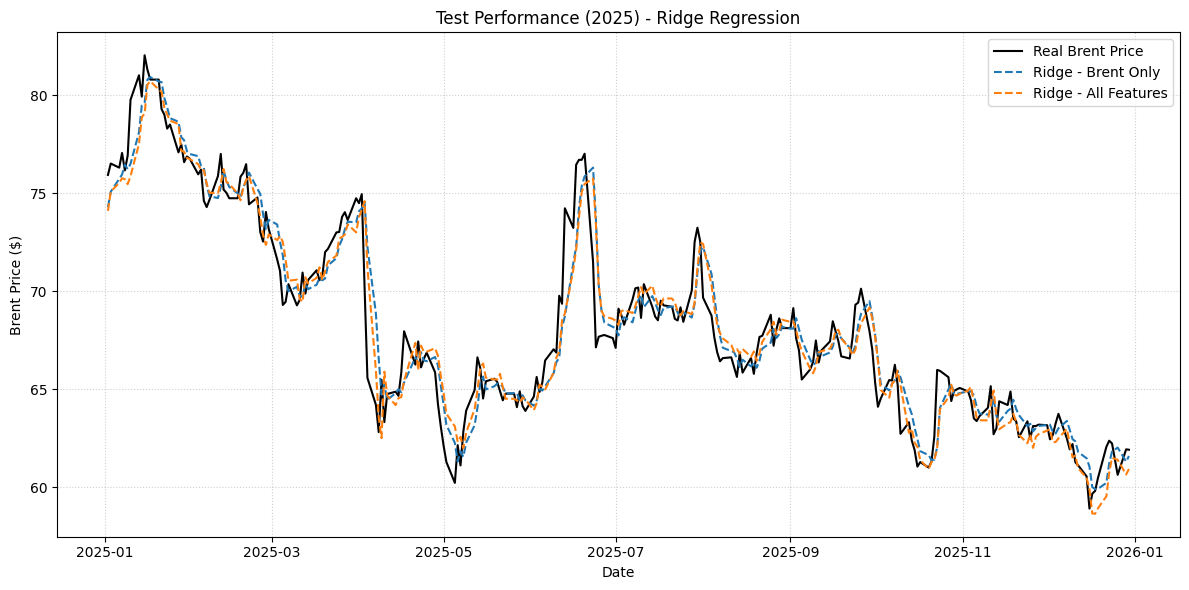

In [ ]:
# ============================================================
# RIDGE REGRESSION - BRENT ONLY vs ALL FEATURES
# ============================================================
print("\n" + "#"*70)
print("RIDGE REGRESSION - COMPARAÇÃO DE FEATURES")
print("#"*70)

num_features = train_df.shape[1]
brent_idx = train_df.columns.get_loc("Brent_Oil")

# Apenas Brent: 10 dias x 1 variável
X_train_ridge_brent = X_train_lstm[:, :, brent_idx].reshape(X_train_lstm.shape[0], -1)
X_val_ridge_brent   = X_val_lstm[:, :, brent_idx].reshape(X_val_lstm.shape[0], -1)
X_test_ridge_brent  = X_test_lstm[:, :, brent_idx].reshape(X_test_lstm.shape[0], -1)

# Todas as variáveis: 10 dias x 12 variáveis
X_train_ridge_all = X_train_rf.copy()
X_val_ridge_all   = X_val_rf.copy()
X_test_ridge_all  = X_test_rf.copy()

print("Shape Ridge somente Brent:", X_train_ridge_brent.shape, X_val_ridge_brent.shape, X_test_ridge_brent.shape)
print("Shape Ridge todas variáveis:", X_train_ridge_all.shape, X_val_ridge_all.shape, X_test_ridge_all.shape)


def inverse_target_values(y_scaled):
    dummy = np.zeros((len(y_scaled), num_features))
    dummy[:, 0] = y_scaled
    return scaler.inverse_transform(dummy)[:, 0]


def run_ridge_experiment(nome, X_train, X_val, X_test):
    print("\n" + "="*70)
    print(nome)
    print("="*70)

    model = Ridge(alpha=1.0)

    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_val_pred_scaled = model.predict(X_val)

    y_val_pred = inverse_target_values(y_val_pred_scaled)
    y_val_real = inverse_target_values(y_val)

    mae_val = mean_absolute_error(y_val_real, y_val_pred)
    rmse_val = np.sqrt(mean_squared_error(y_val_real, y_val_pred))
    mape_val = mean_absolute_percentage_error(y_val_real, y_val_pred) * 100

    print("\nVALIDAÇÃO 2024")
    print(f"MAE:  ${mae_val:.4f}")
    print(f"RMSE: ${rmse_val:.4f}")
    print(f"MAPE: {mape_val:.4f}%")
    print(f"Tempo de treino: {train_time:.4f} segundos")

    X_hist = np.vstack((X_train, X_val))
    y_hist = np.concatenate((y_train, y_val))

    model_final = Ridge(alpha=1.0)
    model_final.fit(X_hist, y_hist)

    y_test_pred_scaled = model_final.predict(X_test)

    y_test_pred = inverse_target_values(y_test_pred_scaled)
    y_test_real = inverse_target_values(y_test)

    mae_test = mean_absolute_error(y_test_real, y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test_real, y_test_pred))
    mape_test = mean_absolute_percentage_error(y_test_real, y_test_pred) * 100

    print("\nTESTE 2025")
    print(f"MAE:  ${mae_test:.4f}")
    print(f"RMSE: ${rmse_test:.4f}")
    print(f"MAPE: {mape_test:.4f}%")

    return y_test_real, y_test_pred, mae_val, rmse_val, mape_val, mae_test, rmse_test, mape_test


ridge_brent = run_ridge_experiment(
    "RIDGE - SOMENTE BRENT",
    X_train_ridge_brent,
    X_val_ridge_brent,
    X_test_ridge_brent
)

ridge_all = run_ridge_experiment(
    "RIDGE - TODAS AS VARIÁVEIS",
    X_train_ridge_all,
    X_val_ridge_all,
    X_test_ridge_all
)

ridge_comparison = pd.DataFrame({
    "Modelo": ["Ridge - Brent", "Ridge - Todas"],
    "MAE Val 2024": [ridge_brent[2], ridge_all[2]],
    "RMSE Val 2024": [ridge_brent[3], ridge_all[3]],
    "MAPE Val 2024": [ridge_brent[4], ridge_all[4]],
    "MAE Test 2025": [ridge_brent[5], ridge_all[5]],
    "RMSE Test 2025": [ridge_brent[6], ridge_all[6]],
    "MAPE Test 2025": [ridge_brent[7], ridge_all[7]],
})

print("\n================ COMPARAÇÃO RIDGE ================")
print(ridge_comparison.round(4))

plt.figure(figsize=(12, 6))
plt.plot(test_df.index, ridge_brent[0], label="Real Brent Price", color="black", linewidth=1.5)
plt.plot(test_df.index, ridge_brent[1], label="Ridge - Brent Only", linestyle="--", linewidth=1.5)
plt.plot(test_df.index, ridge_all[1], label="Ridge - All Features", linestyle="--", linewidth=1.5)
plt.title("Test Performance (2025) - Ridge Regression")
plt.xlabel("Date")
plt.ylabel("Brent Price ($)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

#Random Forest

##Random Forest Hyperparameter Tuning

In [ ]:
param_dist= {
    'n_estimators': [100, 200, 300],      # Número de árvores na floresta
    'max_depth': [10, 15, 20, None],      # Profundidade máxima
    'min_samples_split': [2, 5, 10],      # Mínimo de amostras para abrir um nó
    'max_features': ['sqrt', 'log2', None] # Atributos considerados por divisão
}

#Instanciamos um modelo base do Random Forest
rf_base= RandomForestRegressor(random_state=42, n_jobs=-1)

tscv_treino= TimeSeriesSplit(n_splits=3)

#O tuning recebe única e exclusivamente as matrizes puras de treino (X_train_rf e y_train)
X_tuning= X_train_rf
y_tuning= y_train

#Configura o buscador aleatório para testar apenas 10 combinações
random_search= RandomizedSearchCV(
    estimator= rf_base,
    param_distributions= param_dist,
    n_iter=10,  #Limita rigorosamente a busca a 10 iterações inteligentes
    #Passamos a validação cruzada temporal interna do treino
    cv= tscv_treino,
    scoring="neg_mean_absolute_error",  #Métrica guia: MAE
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

#MEDIÇÃO DO TEMPO E EXECUÇÃO DA BUSCA ALEATÓRIA
print(f"Iniciando o RandomizedSearchCV (Apenas 10 iterações inteligentes no treino)...")
tempo_inicio_random= time.time()

#Executa o treino otimizado
random_search.fit(X_tuning, y_tuning)

tempo_fim_random= time.time()
print(f"\nOtimização concluída com sucesso em {tempo_fim_random - tempo_inicio_random:.4f} segundos")

rf_modelo_otimizado= random_search.best_estimator_

print("\n================ MELHORES HIPERPARÂMETROS ENCONTRADOS ================")
print(random_search.best_params_)
print(f"Melhor MAE interno de cross-validation (Treino): ${abs(random_search.best_score_):.4f}")

Iniciando o RandomizedSearchCV (Apenas 10 iterações inteligentes no treino)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Otimização concluída com sucesso em 286.0459 segundos

================ MELHORES HIPERPARÂMETROS ENCONTRADOS ================
{'n_estimators': 300, 'min_samples_split': 5, 'max_features': None, 'max_depth': 20}
Melhor MAE interno de cross-validation (Treino): $0.0265


##Random Forest Training

In [ ]:
print("Calculando o diagnóstico de ajuste para o Random Forest Otimizado...")
tempo_inicio= time.time()

num_features= train_df.shape[1]

#O modelo já otimizado faz a previsão para todo o bloco de treino de uma só vez de forma estática
y_train_pred_scaled= rf_modelo_otimizado.predict(X_train_rf)

tempo_fim= time.time()
print(f"Tempo de execução da inferência: {tempo_fim - tempo_inicio:.4f} segundos.")

dummy_train_pred= np.zeros((len(y_train_pred_scaled), num_features))
dummy_train_pred[:, 0]= y_train_pred_scaled
y_train_pred_dollars= scaler.inverse_transform(dummy_train_pred)[:, 0]

#Reconstrói a matriz dummy para os valores reais de treino
dummy_train_real= np.zeros((len(y_train), num_features))
dummy_train_real[:, 0]= y_train
y_train_dollars= scaler.inverse_transform(dummy_train_real)[:, 0]

#Cálculo das métricas de treino (MAE e MAPE) para avaliação de overfitting do modelo otimizado
mae_treino= mean_absolute_error(y_train_dollars, y_train_pred_dollars)
mape_treino= mean_absolute_percentage_error(y_train_dollars, y_train_pred_dollars) * 100

print("\n================ DIAGNÓSTICO DE AJUSTE (TREINO HISTÓRICO OTIMIZADO) ================")
print(f"MAE no Treino:  ${mae_treino:.2f}")
print(f"MAPE no Treino: {mape_treino:.2f}%")

Calculando o diagnóstico de ajuste para o Random Forest Otimizado...
Tempo de execução da inferência: 0.1437 segundos.

================ DIAGNÓSTICO DE AJUSTE (TREINO HISTÓRICO OTIMIZADO) ================
MAE no Treino:  $0.44
MAPE no Treino: 0.70%


##Random Forest Validation


Iniciando o Rolling Forecast dinâmico para o ano de Validação (2024)...

================ RESULTADOS RANDOM FOREST (VALIDAÇÃO 2024) ================
MAE em 2024: $1.49
RMSE em 2024: $2.00
MAPE em 2024: 1.86%
Tempo Total de Validação: 22.7625 segundos
Tempo Médio por Predição Diária: 0.086880 segundos (262 dias úteis)


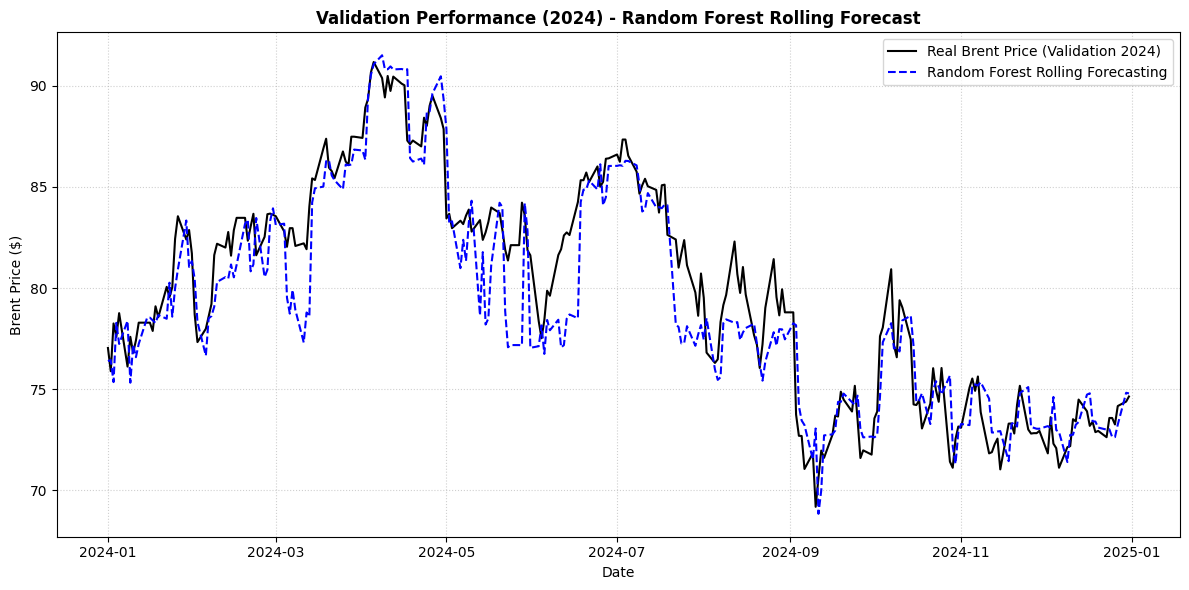

In [ ]:
print("\nIniciando o Rolling Forecast dinâmico para o ano de Validação (2024)...")

#Criamos uma cópia da matriz de VALIDAÇÃO original para manipulação dinâmica
#X_val_rf tem o formato baseado em 10 dias úteis * número de colunas
X_val_dinamico= np.copy(X_val_rf)
rolling_predictions_scaled= []

#Identifica o número de colunas automaticamente baseado no DataFrame de treino
num_features= train_df.shape[1]
tempo_inicio_val= time.time()

for time_point in range(len(y_val)):
    #O modelo faz a previsão para o dia de 2024 baseado na janela disponível
    janela_atual= X_val_dinamico[time_point].reshape(1, -1)
    predicao_atual_scaled= rf_modelo_otimizado.predict(janela_atual)[0]
    rolling_predictions_scaled.append(predicao_atual_scaled)

    #ADAPTAÇÃO DINÂMICA COMPLETA (Para o próximo passo do loop dentro de 2024)
    #Se ainda houver um amanhã dentro do laço de validação, atualizamos todas as features da linha seguinte
    if time_point + 1 < len(y_val):
        #A linha do dia seguinte recebe todas as variáveis reais registradas (o Brent de ontem e as macroeconômicas atualizadas)
        X_val_dinamico[time_point + 1]= X_val_rf[time_point + 1]

tempo_fim_val= time.time()
tempo_total_val= tempo_fim_val - tempo_inicio_val
tempo_medio_diario= tempo_total_val / len(y_val)

#Convertemos a lista final de predições normalizadas em array
rolling_predictions_scaled= np.array(rolling_predictions_scaled)

#TRATAMENTO PARA SCALER MULTIVARIADO (Inversão da Normalização)
#Criando a matriz dummy para as predições de 2024
dummy_pred= np.zeros((len(rolling_predictions_scaled), num_features))
dummy_pred[:, 0]= rolling_predictions_scaled  #Injeta os palpites na coluna idx 0
y_pred_dollars= scaler.inverse_transform(dummy_pred)[:, 0]

#Criando a matriz dummy para o alvo real de validação de 2024
dummy_val= np.zeros((len(y_val), num_features))
dummy_val[:, 0]= y_val  #Injeta os valores reais na coluna idx 0
y_val_dollars= scaler.inverse_transform(dummy_val)[:, 0]

#AVALIAÇÃO DE DESEMPENHO NA VALIDAÇÃO (O Trio Dinâmico: MAE, RMSE, MAPE)
mae_rf= mean_absolute_error(y_val_dollars, y_pred_dollars)
rmse_rf= np.sqrt(mean_squared_error(y_val_dollars, y_pred_dollars))
mape_rf= mean_absolute_percentage_error(y_val_dollars, y_pred_dollars) * 100
print("\n================ RESULTADOS RANDOM FOREST (VALIDAÇÃO 2024) ================")
print(f"MAE em 2024: ${mae_rf:.2f}")
print(f"RMSE em 2024: ${rmse_rf:.2f}")
print(f"MAPE em 2024: {mape_rf:.2f}%")
print(f"Tempo Total de Validação: {tempo_total_val:.4f} segundos")
print(f"Tempo Médio por Predição Diária: {tempo_medio_diario:.6f} segundos ({len(y_val)} dias úteis)")

datas_validacao= val_df.index #alinha as datas usando o index do val_df
plt.figure(figsize=(12, 6))
plt.plot(datas_validacao, y_val_dollars, label='Real Brent Price (Validation 2024)', color='black', linewidth=1.5)
plt.plot(datas_validacao, y_pred_dollars, label='Random Forest Rolling Forecasting', color='blue', linestyle='--', linewidth=1.5)
plt.title('Validation Performance (2024) - Random Forest Rolling Forecast', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Brent Price ($)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

##Diagnóstico de Possível Overfitting

In [ ]:
# ============================================================
# Diagnóstico de Overfitting - Random Forest
# ============================================================

print("\n================ DIAGNÓSTICO DE OVERFITTING - RANDOM FOREST ================")

# Predição no treino
y_train_pred_scaled_rf = rf_modelo_otimizado.predict(X_train_rf)

dummy_train_pred = np.zeros((len(y_train_pred_scaled_rf), num_features))
dummy_train_pred[:, 0] = y_train_pred_scaled_rf
y_train_pred_dollars_rf = scaler.inverse_transform(dummy_train_pred)[:, 0]

dummy_train_real = np.zeros((len(y_train), num_features))
dummy_train_real[:, 0] = y_train
y_train_dollars_rf = scaler.inverse_transform(dummy_train_real)[:, 0]

mae_train_rf = mean_absolute_error(y_train_dollars_rf, y_train_pred_dollars_rf)
rmse_train_rf = np.sqrt(mean_squared_error(y_train_dollars_rf, y_train_pred_dollars_rf))
mape_train_rf = mean_absolute_percentage_error(y_train_dollars_rf, y_train_pred_dollars_rf) * 100

# Predição na validação
y_val_pred_scaled_rf = rf_modelo_otimizado.predict(X_val_rf)

dummy_val_pred = np.zeros((len(y_val_pred_scaled_rf), num_features))
dummy_val_pred[:, 0] = y_val_pred_scaled_rf
y_val_pred_dollars_rf = scaler.inverse_transform(dummy_val_pred)[:, 0]

dummy_val_real = np.zeros((len(y_val), num_features))
dummy_val_real[:, 0] = y_val
y_val_dollars_rf = scaler.inverse_transform(dummy_val_real)[:, 0]

mae_val_rf = mean_absolute_error(y_val_dollars_rf, y_val_pred_dollars_rf)
rmse_val_rf = np.sqrt(mean_squared_error(y_val_dollars_rf, y_val_pred_dollars_rf))
mape_val_rf = mean_absolute_percentage_error(y_val_dollars_rf, y_val_pred_dollars_rf) * 100

gap_mae_rf = mae_val_rf - mae_train_rf

print(f"MAE Treino:     ${mae_train_rf:.2f}")
print(f"RMSE Treino:    ${rmse_train_rf:.2f}")
print(f"MAPE Treino:    {mape_train_rf:.2f}%")
print()
print(f"MAE Validação:  ${mae_val_rf:.2f}")
print(f"RMSE Validação: ${rmse_val_rf:.2f}")
print(f"MAPE Validação: {mape_val_rf:.2f}%")
print()
print(f"Gap MAE Validação - Treino: ${gap_mae_rf:.2f}")


================ DIAGNÓSTICO DE OVERFITTING - RANDOM FOREST ================
MAE Treino:     $0.44
RMSE Treino:    $0.66
MAPE Treino:    0.70%

MAE Validação:  $1.49
RMSE Validação: $2.00
MAPE Validação: 1.86%

Gap MAE Validação - Treino: $1.04


##Random Forest - Freios de Overfitting

In [ ]:
# ============================================================
# Random Forest - Freios de Overfitting
# [A] max_depth, [B] min_samples_leaf, [C] combinação
# ============================================================

print("\n" + "="*70)
print("FASE 3 - FREIOS DE OVERFITTING DO RANDOM FOREST (VALIDAÇÃO)")
print("="*70)
print("Leitura: apertar o freio reduz o ajuste ao treino.")
print("O melhor freio é o que minimiza o MAE de validação, não necessariamente o que zera o gap.\n")

MAX_DEPTHS = [3, 5, 10, 15, None]
MIN_LEAVES = [1, 5, 20, 50]

BASE_PARAMS = {
    "n_estimators": 100,
    "random_state": 42,
    "n_jobs": -1
}


def inverse_target_rf(y_scaled):
    dummy = np.zeros((len(y_scaled), num_features))
    dummy[:, 0] = y_scaled
    return scaler.inverse_transform(dummy)[:, 0]


def avaliar_freio_rf(params, label):
    modelo = RandomForestRegressor(**params)

    t0 = time.time()
    modelo.fit(X_train_rf, y_train)
    tempo = time.time() - t0

    y_train_pred_scaled = modelo.predict(X_train_rf)
    y_val_pred_scaled = modelo.predict(X_val_rf)

    y_train_pred = inverse_target_rf(y_train_pred_scaled)
    y_val_pred = inverse_target_rf(y_val_pred_scaled)

    y_train_real = inverse_target_rf(y_train)
    y_val_real = inverse_target_rf(y_val)

    mae_train = mean_absolute_error(y_train_real, y_train_pred)
    mae_val = mean_absolute_error(y_val_real, y_val_pred)

    rmse_train = np.sqrt(mean_squared_error(y_train_real, y_train_pred))
    rmse_val = np.sqrt(mean_squared_error(y_val_real, y_val_pred))

    mape_train = mean_absolute_percentage_error(y_train_real, y_train_pred) * 100
    mape_val = mean_absolute_percentage_error(y_val_real, y_val_pred) * 100

    return {
        "ajuste": label,
        "MAE_treino": mae_train,
        "MAE_eval": mae_val,
        "gap_MAE": mae_val - mae_train,
        "RMSE_treino": rmse_train,
        "RMSE_eval": rmse_val,
        "MAPE_treino": mape_train,
        "MAPE_eval": mape_val,
        "tempo_s": tempo
    }


# ============================================================
# [A] Variando max_depth
# ============================================================

print("\n--- [A] Variando max_depth (min_samples_leaf=1) ---")

rows_a = []

for max_depth in MAX_DEPTHS:
    params = {
        **BASE_PARAMS,
        "max_depth": max_depth,
        "min_samples_leaf": 1
    }

    rows_a.append(
        avaliar_freio_rf(
            params,
            f"max_depth={max_depth}"
        )
    )

df_a = pd.DataFrame(rows_a).set_index("ajuste")

print(df_a.round(4).to_string())


# ============================================================
# [B] Variando min_samples_leaf
# ============================================================

print("\n--- [B] Variando min_samples_leaf (max_depth=None) ---")

rows_b = []

for min_leaf in MIN_LEAVES:
    params = {
        **BASE_PARAMS,
        "max_depth": None,
        "min_samples_leaf": min_leaf
    }

    rows_b.append(
        avaliar_freio_rf(
            params,
            f"min_leaf={min_leaf}"
        )
    )

df_b = pd.DataFrame(rows_b).set_index("ajuste")

print(df_b.round(4).to_string())


# ============================================================
# [C] Combinando melhor max_depth + melhor min_samples_leaf
# ============================================================

best_a = min(rows_a, key=lambda row: row["MAE_eval"])
best_b = min(rows_b, key=lambda row: row["MAE_eval"])

best_md_label = best_a["ajuste"]
best_ml_label = best_b["ajuste"]

md_text = best_md_label.split("=")[1]
ml_text = best_ml_label.split("=")[1]

best_max_depth = None if md_text == "None" else int(md_text)
best_min_leaf = int(ml_text)

print("\n--- [C] Combinação do melhor de cada eixo ---")
print(f"Melhor [A]: {best_md_label}")
print(f"Melhor [B]: {best_ml_label}")

params_c = {
    **BASE_PARAMS,
    "max_depth": best_max_depth,
    "min_samples_leaf": best_min_leaf
}

row_c = avaliar_freio_rf(
    params_c,
    f"max_depth={best_max_depth}, min_leaf={best_min_leaf}"
)

df_c = pd.DataFrame([row_c]).set_index("ajuste")

print(df_c.round(4).to_string())


# ============================================================
# Resumo final
# ============================================================

df_rf_freios_resumo = pd.concat([
    df_a.assign(grupo="A - max_depth"),
    df_b.assign(grupo="B - min_samples_leaf"),
    df_c.assign(grupo="C - combinado")
])

print("\n================ RESUMO FINAL - FREIOS RF ================")
print(df_rf_freios_resumo.round(4).to_string())


FASE 3 - FREIOS DE OVERFITTING DO RANDOM FOREST (VALIDAÇÃO)
Leitura: apertar o freio reduz o ajuste ao treino.
O melhor freio é o que minimiza o MAE de validação, não necessariamente o que zera o gap.


--- [A] Variando max_depth (min_samples_leaf=1) ---
                MAE_treino  MAE_eval  gap_MAE  RMSE_treino  RMSE_eval  MAPE_treino  MAPE_eval  tempo_s
ajuste                                                                                                
max_depth=3         2.3279    2.2173  -0.1106       3.0299     2.5949       3.9382     2.8011   6.4771
max_depth=5         1.0319    1.0817   0.0499       1.4584     1.3898       1.6423     1.3638  11.9119
max_depth=10        0.5440    1.4811   0.9371       0.7298     2.0240       0.8438     1.8510  22.0038
max_depth=15        0.4218    1.4016   0.9798       0.6127     1.8558       0.6572     1.7528  26.7819
max_depth=None      0.4160    1.4056   0.9896       0.6091     1.8734       0.6482     1.7578  27.9023

--- [B] Variando min_s

## Random Forest - Teste com Melhor Configuração de Parâmetros Encontrada


RANDOM FOREST FINAL - TESTE 2025
Configuração final escolhida pelos freios:
{'n_estimators': 100, 'random_state': 42, 'n_jobs': -1, 'max_depth': 5, 'min_samples_leaf': 20}

================ RESULTADOS RANDOM FOREST (TESTE 2025) ================
MAE em 2025:  $0.9527
RMSE em 2025: $1.2963
MAPE em 2025: 1.3967%
Tempo Total de Teste: 12.2850 segundos
Tempo Médio por Predição Diária: 0.047802 segundos (257 dias úteis)


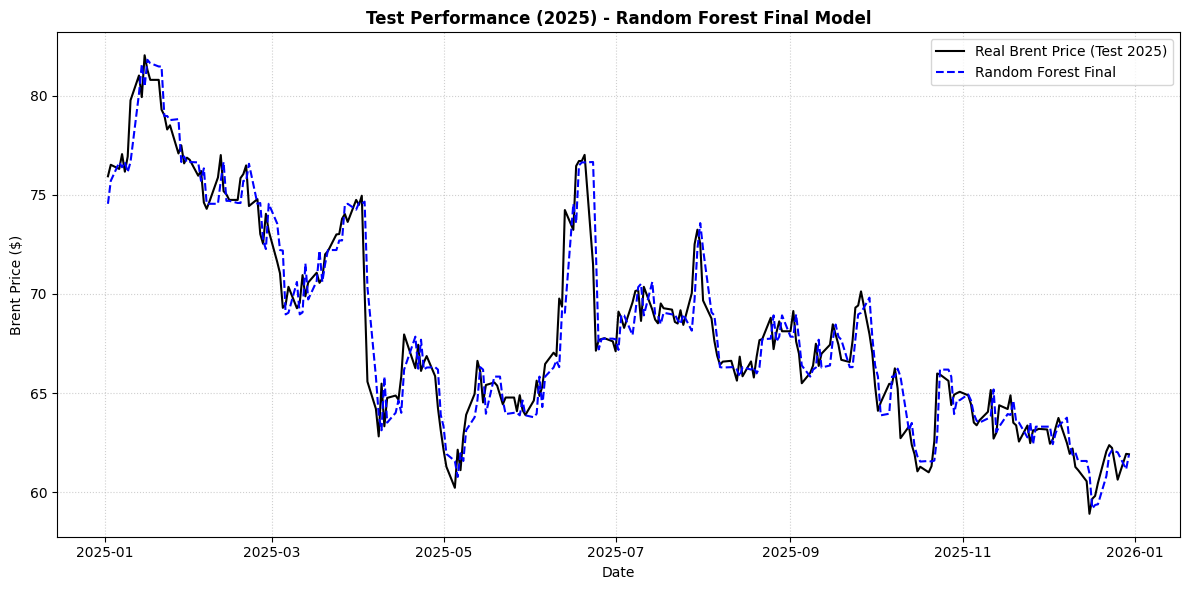

In [ ]:
# ============================================================
# Random Forest - Teste Final 2025 com melhor freio encontrado
# ============================================================

print("\n" + "="*70)
print("RANDOM FOREST FINAL - TESTE 2025")
print("="*70)

print("Configuração final escolhida pelos freios:")
print(params_c)

# Junta treino + validação para treinar o modelo final antes do teste
X_trainval_rf = np.vstack([X_train_rf, X_val_rf])
y_trainval_rf = np.concatenate([y_train, y_val])

# Treina o modelo final com a melhor configuração encontrada em [C]
rf_final = RandomForestRegressor(**params_c)

tempo_inicio_rf_test = time.time()

rf_final.fit(X_trainval_rf, y_trainval_rf)

# Predição no teste 2025
y_test_pred_scaled_rf = rf_final.predict(X_test_rf)

tempo_fim_rf_test = time.time()
tempo_total_rf_test = tempo_fim_rf_test - tempo_inicio_rf_test
tempo_medio_rf_test = tempo_total_rf_test / len(y_test)

# Inverte escala das predições
y_pred_dollars_rf_test = inverse_target_rf(y_test_pred_scaled_rf)

# Inverte escala dos valores reais
y_test_dollars_rf = inverse_target_rf(y_test)

# Métricas no teste
mae_rf_test = mean_absolute_error(y_test_dollars_rf, y_pred_dollars_rf_test)
rmse_rf_test = np.sqrt(mean_squared_error(y_test_dollars_rf, y_pred_dollars_rf_test))
mape_rf_test = mean_absolute_percentage_error(y_test_dollars_rf, y_pred_dollars_rf_test) * 100

print("\n================ RESULTADOS RANDOM FOREST (TESTE 2025) ================")
print(f"MAE em 2025:  ${mae_rf_test:.4f}")
print(f"RMSE em 2025: ${rmse_rf_test:.4f}")
print(f"MAPE em 2025: {mape_rf_test:.4f}%")
print(f"Tempo Total de Teste: {tempo_total_rf_test:.4f} segundos")
print(f"Tempo Médio por Predição Diária: {tempo_medio_rf_test:.6f} segundos ({len(y_test)} dias úteis)")

# Salva as séries para gráfico consolidado depois
rf_pred_test_series = pd.Series(y_pred_dollars_rf_test, index=test_df.index)
real_test_series = pd.Series(y_test_dollars_rf, index=test_df.index)

# Plot individual
plt.figure(figsize=(12, 6))
plt.plot(
    test_df.index,
    y_test_dollars_rf,
    label="Real Brent Price (Test 2025)",
    color="black",
    linewidth=1.5
)

plt.plot(
    test_df.index,
    y_pred_dollars_rf_test,
    label="Random Forest Final",
    color="blue",
    linestyle="--",
    linewidth=1.5
)

plt.title(
    "Test Performance (2025) - Random Forest Final Model",
    fontsize=12,
    fontweight="bold"
)
plt.xlabel("Date")
plt.ylabel("Brent Price ($)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

#Support Vector Regression

##Support Vector Regression Hyperparameter Tuning

In [ ]:
param_dist_svr= {
    "C": [0.1, 1.0, 10.0, 100.0, 1000.0], #Valores altos combatem o underfitting
    "epsilon": [0.001, 0.005, 0.01, 0.05, 0.1], #Margens estreitas forçam precisão
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1] #Controla a curvatura do RBF
}

#Instanciamos o modelo base do SVR com o kernel RBF
svr_base= SVR(kernel="rbf")

tscv_treino_svr= TimeSeriesSplit(n_splits=3)

#O tuning do SVR recebe exclusivamente as matrizes puras de treino (X_train_rf e y_train)
X_tuning_svr= X_train_rf
y_tuning_svr= y_train

#Configura o buscador aleatório para o SVR
random_search_svr= RandomizedSearchCV(
    estimator=svr_base,
    param_distributions=param_dist_svr,
    n_iter=10, #limita a busca a 10 combinações para rodar mais rápido
    #Passamos a validação cruzada temporal interna do treino
    cv= tscv_treino_svr,
    scoring="neg_mean_absolute_error", #Métrica guia: MAE
    n_jobs=-1,
    random_state=42,
    verbose=1
)

#MEDIÇÃO DO TEMPO E EXECUÇÃO DA BUSCA NO SVR
print("Iniciando o RandomizedSearchCV para o SVR (Apenas no treino)...")
tempo_inicio_random_svr= time.time()

#Executa o treino otimizado do SVR usando apenas o bloco histórico puro
#Passagem das variáveis exclusivas de treino mapeadas para o SVR
random_search_svr.fit(X_tuning_svr, y_tuning_svr)

tempo_fim_random_svr= time.time()
print(f"\nOtimização do SVR concluída com sucesso em {tempo_fim_random_svr - tempo_inicio_random_svr:.4f} segundos")

svr_modelo_otimizado= random_search_svr.best_estimator_
print("\n================ MELHORES HIPERPARÂMETROS ENCONTRADOS (SVR) ================")
print(random_search_svr.best_params_)
print(f"Melhor MAE interno de cross-validation (Treino SVR): ${abs(random_search_svr.best_score_):.4f}")

Iniciando o RandomizedSearchCV para o SVR (Apenas no treino)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Otimização do SVR concluída com sucesso em 12.9959 segundos

================ MELHORES HIPERPARÂMETROS ENCONTRADOS (SVR) ================
{'gamma': 'auto', 'epsilon': 0.01, 'C': 1.0}
Melhor MAE interno de cross-validation (Treino SVR): $0.0382


##Support Vector Regression Training

In [ ]:
print("Calculando o diagnóstico de ajuste para o SVR Otimizado...")
tempo_inicio= time.time()

num_features= train_df.shape[1]

#O modelo já otimizado faz a previsão para todo o bloco de treino de uma só vez
#Aqui usamos o modelo que veio do  tuning
y_train_pred_scaled_svr= svr_modelo_otimizado.predict(X_train_rf)

tempo_fim= time.time()
print(f"Tempo de execução da inferência: {tempo_fim - tempo_inicio:.4f} segundos.")

#Reconstrói a matriz dummy para inverter a normalização das predições de treino
dummy_train_pred_svr= np.zeros((len(y_train_pred_scaled_svr), num_features))
dummy_train_pred_svr[:, 0]= y_train_pred_scaled_svr
y_train_pred_dollars_svr= scaler.inverse_transform(dummy_train_pred_svr)[:, 0]

#Reconstrói a matriz dummy para os valores reais de treino
dummy_train_real= np.zeros((len(y_train), num_features))
dummy_train_real[:, 0]= y_train
y_train_dollars= scaler.inverse_transform(dummy_train_real)[:, 0]

#Cálculo das duas métricas de avaliação ao final para o modelo otimizado
mae_treino_svr= mean_absolute_error(y_train_dollars, y_train_pred_dollars_svr)
mape_treino_svr= mean_absolute_percentage_error(y_train_dollars, y_train_pred_dollars_svr) * 100

print("\n================ DIAGNÓSTICO DE AJUSTE (TREINO HISTÓRICO SVR OTIMIZADO) ================")
print(f"MAE no Treino:  ${mae_treino_svr:.2f}")
print(f"MAPE no Treino: {mape_treino_svr:.2f}%")

Calculando o diagnóstico de ajuste para o SVR Otimizado...
Tempo de execução da inferência: 0.8879 segundos.

================ DIAGNÓSTICO DE AJUSTE (TREINO HISTÓRICO SVR OTIMIZADO) ================
MAE no Treino:  $1.26
MAPE no Treino: 2.00%


##Support Vector Regression Validation

Iniciando a simulação do mercado diário para o ano de Validação (2024) com SVR...

============== RESULTADOS SUPPORT VECTOR REGRESSION (VALIDAÇÃO 2024) ================
MAE (2024): $1.46
RMSE (2024): $1.85
MAPE (2024): 1.88%
Tempo Total de Validação: 0.1028 segundos
Tempo Médio por Predição Diária: 0.000392 segundos (262 dias úteis)


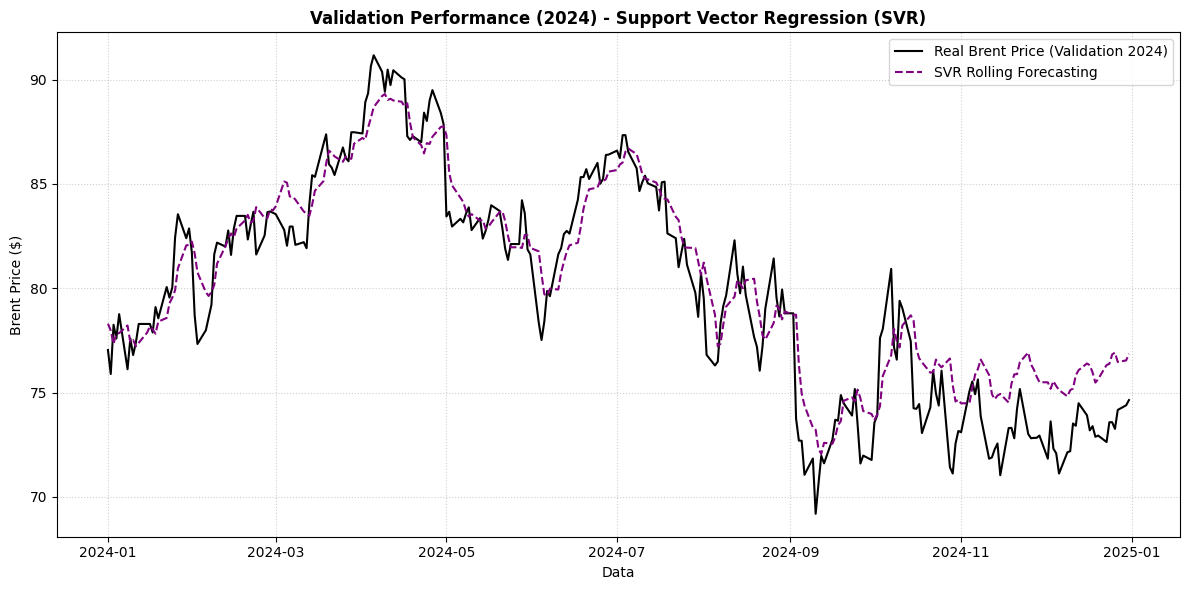

In [ ]:
print("Iniciando a simulação do mercado diário para o ano de Validação (2024) com SVR...")

#Cria uma cópia da matriz de validação do pré-processamento para atualizar os lags dinamicamente
X_val_dinamico_svr= np.copy(X_val_rf)
rolling_predictions_scaled_svr= []

#Identifica automaticamente o número de features (colunas) usando o DataFrame original
num_features= train_df.shape[1]
tempo_inicio_val_svr= time.time()

for time_point in range(len(y_val)):
    #1. Faz a predição para o dia atual com base no histórico recente de 10 dias
    janela_atual= X_val_dinamico_svr[time_point].reshape(1, -1)
    predicao_atual_scaled= svr_modelo_otimizado.predict(janela_atual)[0]
    rolling_predictions_scaled_svr.append(predicao_atual_scaled)

    #2. Adaptação temporal para o próximo passo do loop
    if time_point + 1 < len(y_val):
        X_val_dinamico_svr[time_point + 1]= X_val_rf[time_point + 1]

tempo_fim_val_svr= time.time()
tempo_total_val_svr= tempo_fim_val_svr - tempo_inicio_val_svr
tempo_medio_diario_svr= tempo_total_val_svr / len(y_val)

#Transforma a lista de resultados em um vetor estruturado do NumPy
rolling_predictions_scaled_svr= np.array(rolling_predictions_scaled_svr)

#INVERSÃO DA NORMALIZAÇÃO (Retorno para a escala real em dólares)
#Reconstrói a matriz dummy para as predições do SVR
dummy_pred_svr= np.zeros((len(rolling_predictions_scaled_svr), num_features))
dummy_pred_svr[:, 0]= rolling_predictions_scaled_svr
y_pred_dollars_svr= scaler.inverse_transform(dummy_pred_svr)[:, 0]

#Reconstrói a matriz dummy para os valores reais de validação
dummy_val= np.zeros((len(y_val), num_features))
dummy_val[:, 0]= y_val
y_val_dollars= scaler.inverse_transform(dummy_val)[:, 0]

#CÁLCULO DO TRIO DINÂMICO DE MÉTRICAS RECOMENDADO
mae_svr= mean_absolute_error(y_val_dollars, y_pred_dollars_svr)
rmse_svr= np.sqrt(mean_squared_error(y_val_dollars, y_pred_dollars_svr))
mape_svr= mean_absolute_percentage_error(y_val_dollars, y_pred_dollars_svr) * 100

print("\n============== RESULTADOS SUPPORT VECTOR REGRESSION (VALIDAÇÃO 2024) ================")
print(f"MAE (2024): ${mae_svr:.2f}")
print(f"RMSE (2024): ${rmse_svr:.2f}")
print(f"MAPE (2024): {mape_svr:.2f}%")
print(f"Tempo Total de Validação: {tempo_total_val_svr:.4f} segundos")
print(f"Tempo Médio por Predição Diária: {tempo_medio_diario_svr:.6f} segundos ({len(y_val)} dias úteis)")

#PLOTAGEM DO GRÁFICO DA VALIDAÇÃO (SVR)
datas_validacao= val_df.index

plt.figure(figsize=(12, 6))
plt.plot(datas_validacao, y_val_dollars, label="Real Brent Price (Validation 2024)", color="black", linewidth=1.5)
plt.plot(datas_validacao, y_pred_dollars_svr, label="SVR Rolling Forecasting", color="purple", linestyle="--", linewidth=1.5)
plt.title("Validation Performance (2024) - Support Vector Regression (SVR)", fontsize=12, fontweight="bold")
plt.xlabel("Data")
plt.ylabel("Brent Price ($)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

#Long Short Term Memory

##Long Short Term Memory Hyperparameter Tuning

In [ ]:
device= torch.device("cuda" if torch.cuda.is_available() else "cpu")

#DEFINIÇÃO DA CLASSE DA REDE NEURAL LSTM EM PYTORCH
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super(LSTMModel, self).__init__()
        #Camada LSTM idêntica à do plano original
        self.lstm= nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.dropout= nn.Dropout(dropout_rate)
        #Camada linear de saída para regressão
        self.fc= nn.Linear(hidden_dim, 1)

    def forward(self, x):
        #Passa pela LSTM e recolhe apenas o output do último passo temporal
        out, _= self.lstm(x)
        out= self.dropout(out[:, -1, :])
        out= self.fc(out)
        return out

#PREPARAÇÃO DOS DADOS PARA O PYTORCH (Tensores 3D)
X_train_t= torch.tensor(X_train_lstm, dtype=torch.float32).to(device)
y_train_t= torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
X_val_t= torch.tensor(X_val_lstm, dtype=torch.float32).to(device)
y_val_t= torch.tensor(y_val, dtype=torch.float32).view(-1, 1).to(device)

train_loader= DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=False)

#ESPAÇO DE HIPERPARÂMETROS E SORTEIO ALEATÓRIO RIGOROSO
opcoes_units= [32, 64, 96, 128]
opcoes_dropout= [0.1, 0.2, 0.3]
opcoes_lr= [1e-2, 1e-3, 1e-4]

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

#Criação da malha completa combinando todas as opções de parâmetros
todas_combinacoes= []
for u, d, lr in itertools.product(opcoes_units, opcoes_dropout, opcoes_lr):
    todas_combinacoes.append({"units": u, "dropout": d, "learning_rate": lr})

n_iter= 15  #quantas combinações aleatórias o modelo deve testar
n_iter= min(n_iter, len(todas_combinacoes)) #garante que não sorteie mais do que o total
combinacoes_sorteadas= random.sample(todas_combinacoes, n_iter)

total_testes= len(combinacoes_sorteadas)
tscv_treino= TimeSeriesSplit(n_splits=3)

#RANDOM SEARCH RESTRITO AO TREINO
print(f"Iniciando o Random Search com Validação Cruzada para a LSTM ({total_testes} combinações no treino)...")
tempo_inicio_random= time.time()

#Controle do melhor erro baseado no MAE médio obtido nos splits internos do treino
melhor_mae_interno_treino= float("inf")
melhores_hiperparametros= None
input_dim= X_train_lstm.shape[2] #número de colunas originais
num_features= train_df.shape[1]  #usado para a desnormalização

#Loop percorrendo as combinações sorteadas da malha
for i, config in enumerate(combinacoes_sorteadas):
    print(f"\n[Iteração {i+1}/{total_testes}] Testando: Units={config['units']} | Dropout={config['dropout']} | LR={config['learning_rate']}")

    #Lista para acumular os erros de dólares de cada um dos 3 splits temporais internos
    maes_splits_internos= []

    #Laço interno que executa a validação cruzada temporal dentro das matrizes de treino originais
    for fold, (train_idx, val_idx) in enumerate(tscv_treino.split(X_train_lstm)):

        #Geração dos sub-blocos tensores baseados nos índices do TimeSeriesSplit
        X_tr_fold= torch.tensor(X_train_lstm[train_idx], dtype=torch.float32).to(device)
        y_tr_fold= torch.tensor(y_train[train_idx], dtype=torch.float32).view(-1, 1).to(device)
        X_va_fold= torch.tensor(X_train_lstm[val_idx], dtype=torch.float32).to(device)
        y_va_fold= y_train[val_idx] #Mantido em numpy para calcular o MAE real ao fim

        #DataLoader montado dinamicamente para o sub-bloco de treino do fold atual
        fold_loader= DataLoader(TensorDataset(X_tr_fold, y_tr_fold), batch_size=32, shuffle=False)

        modelo= LSTMModel(input_dim, config["units"], config["dropout"]).to(device)
        criterion= nn.L1Loss()
        optimizer= optim.Adam(modelo.parameters(), lr=config["learning_rate"])
        paciencia= 6  #quantas épocas esperar se o erro não cair
        epochs_sem_melhora= 0
        melhor_loss_fold= float("inf")

        #Treinamento de 45 épocas para garantir convergência matemática estável em cada fold
        for epoch in range(45):
            modelo.train()
            for batch_X, batch_y in fold_loader:
                optimizer.zero_grad()
                outputs= modelo(batch_X)
                loss= criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
            modelo.eval()
            with torch.no_grad():
              val_preds_scaled= modelo(X_va_fold)
              #Calcula a perda da validação ainda na escala normalizada (mais rápido)
              val_loss_atual= criterion(val_preds_scaled, torch.tensor(y_va_fold, dtype=torch.float32).view(-1, 1).to(device))

            #Verificação do EARLY STOPPING
            if val_loss_atual.item() < melhor_loss_fold:
              melhor_loss_fold= val_loss_atual.item()
              epochs_sem_melhora= 0
            else:
              epochs_sem_melhora += 1
            if epochs_sem_melhora >= paciencia: #modelo parou de aprender e começou a decorar. Interrompe o laço.
             break

        #Avaliação estática no sub-bloco de validação interna do fold
        modelo.eval()
        with torch.no_grad():
            preds_val_scaled= modelo(X_va_fold).cpu().numpy().flatten()

        #Inversão da Normalização para o cálculo do erro na escala correta da moeda
        dummy_pred_val= np.zeros((len(preds_val_scaled), num_features))
        dummy_pred_val[:, 0]= preds_val_scaled
        preds_val_dollars= scaler.inverse_transform(dummy_pred_val)[:, 0]

        dummy_real_val= np.zeros((len(y_va_fold), num_features))
        dummy_real_val[:, 0]= y_va_fold
        y_val_dollars= scaler.inverse_transform(dummy_real_val)[:, 0]

        mae_fold_dollars= mean_absolute_error(y_val_dollars, preds_val_dollars)
        maes_splits_internos.append(mae_fold_dollars)

    #Extração do MAE médio acumulado através dos 3 testes do passado histórico
    mae_medio_itercao= np.mean(maes_splits_internos)
    print(f"-> MAE Médio de Cross-Validation obtido: ${mae_medio_itercao:.2f}")

    #Comparação baseada no erro interno médio para salvar os hiperparâmetros campeões reais
    if mae_medio_itercao < melhor_mae_interno_treino:
        melhor_mae_interno_treino= mae_medio_itercao
        melhores_hiperparametros= config

tempo_fim_random= time.time()
print(f"\nOtimização aleatória (Random Search) baseada em Cross-Validation concluída em {tempo_fim_random - tempo_inicio_random:.3f} segundos")

print("\n================ MELHORES HIPERPARÂMETROS DEFINITIVOS (LSTM) ================")
print(f"Melhor número de neurónios (units): {melhores_hiperparametros['units']}")
print(f"Melhor taxa de Dropout:            {melhores_hiperparametros['dropout']}")
print(f"Melhor taxa de aprendizagem (LR):  {melhores_hiperparametros['learning_rate']}")
print(f"Melhor MAE interno de cross-validation (Treino LSTM): ${melhor_mae_interno_treino:.2f}")

Iniciando o Random Search com Validação Cruzada para a LSTM (15 combinações no treino)...

[Iteração 1/15] Testando: Units=32 | Dropout=0.3 | LR=0.001
-> MAE Médio de Cross-Validation obtido: $9.89

[Iteração 2/15] Testando: Units=32 | Dropout=0.1 | LR=0.001
-> MAE Médio de Cross-Validation obtido: $9.97

[Iteração 3/15] Testando: Units=64 | Dropout=0.3 | LR=0.0001
-> MAE Médio de Cross-Validation obtido: $5.94

[Iteração 4/15] Testando: Units=64 | Dropout=0.3 | LR=0.01
-> MAE Médio de Cross-Validation obtido: $10.38

[Iteração 5/15] Testando: Units=64 | Dropout=0.2 | LR=0.0001
-> MAE Médio de Cross-Validation obtido: $6.61

[Iteração 6/15] Testando: Units=32 | Dropout=0.2 | LR=0.001
-> MAE Médio de Cross-Validation obtido: $9.62

[Iteração 7/15] Testando: Units=96 | Dropout=0.2 | LR=0.0001
-> MAE Médio de Cross-Validation obtido: $8.85

[Iteração 8/15] Testando: Units=32 | Dropout=0.2 | LR=0.01
-> MAE Médio de Cross-Validation obtido: $10.41

[Iteração 9/15] Testando: Units=96 | Dropo

##Long Short Term Memory Training

In [ ]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("Instanciando o modelo LSTM Otimizado definitivo...")
tempo_inicio= time.time()

#Reconstrói a arquitetura vencedora do PyTorch
lstm_modelo_otimizado= LSTMModel(
    input_dim= X_train_lstm.shape[2],
    hidden_dim= melhores_hiperparametros["units"],
    dropout_rate= melhores_hiperparametros["dropout"]
).to(device)

criterion_definitivo= nn.L1Loss()
optimizer_definitivo= optim.Adam(lstm_modelo_otimizado.parameters(), lr=melhores_hiperparametros["learning_rate"])

#TREINAMENTO EXPANDIDO COM MECANISMO DE EARLY STOPPING
print("Treinando o modelo LSTM com os dados de Treino...")
#Aumentamos para 500 épocas para garantir a convergência matemática do gradiente
epochs_maximas= 500
paciencia_early_stopping= 30
melhor_loss_treino= float("inf")
contador_paciencia= 0

for epoch in range(epochs_maximas):
    lstm_modelo_otimizado.train()
    loss_acumulada_epoca= 0.0

    for batch_X, batch_y in train_loader:
        optimizer_definitivo.zero_grad()
        outputs= lstm_modelo_otimizado(batch_X)
        loss= criterion_definitivo(outputs, batch_y)
        loss.backward()
        optimizer_definitivo.step()
        loss_acumulada_epoca += loss.item()

    loss_media_epoca= loss_acumulada_epoca / len(train_loader)

    #Gatilho do Early Stopping para monitorar a convergência a cada 10 épocas no terminal
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"-> Época [{epoch+1}/{epochs_maximas}] - Loss Média: {loss_media_epoca:.6f}")

    if loss_media_epoca < melhor_loss_treino:
        melhor_loss_treino= loss_media_epoca
        contador_paciencia= 0
        #Salva o estado dos pesos ideais na memória
        torch.save(lstm_modelo_otimizado.state_dict(), "melhor_lstm_pesos.pth")
    else:
        contador_paciencia += 1
        if contador_paciencia >= paciencia_early_stopping:
            print(f"-> Parada antecipada (Early Stopping) ativada na época {epoch+1}!")
            break

#Carrega de volta os melhores pesos que convergiram durante o treino
lstm_modelo_otimizado.load_state_dict(torch.load("melhor_lstm_pesos.pth"))

tempo_fim= time.time()
print(f"Treinamento concluído in {tempo_fim - tempo_inicio:.4f} segundos.")

num_features= train_df.shape[1]

#DIAGNÓSTICO DE AJUSTE NO CONJUNTO DE TREINO HISTÓRICO CONVERGIDO
lstm_modelo_otimizado.eval()
with torch.no_grad():
    y_train_pred_scaled_lstm= lstm_modelo_otimizado(X_train_t).cpu().numpy().flatten()

#Reconstrói a matriz dummy para inverter a normalização das predições de treino
dummy_train_pred_lstm= np.zeros((len(y_train_pred_scaled_lstm), num_features))
dummy_train_pred_lstm[:, 0]= y_train_pred_scaled_lstm
y_train_pred_dollars_lstm= scaler.inverse_transform(dummy_train_pred_lstm)[:, 0]

#Reconstrói a matriz dummy para os valores reais de treino
dummy_train_real= np.zeros((len(y_train), num_features))
dummy_train_real[:, 0]= y_train
y_train_dollars= scaler.inverse_transform(dummy_train_real)[:, 0]

#Cálculo das métricas de avaliação ao final para o diagnóstico
mae_treino_lstm= mean_absolute_error(y_train_dollars, y_train_pred_dollars_lstm)
mape_treino_lstm= mean_absolute_percentage_error(y_train_dollars, y_train_pred_dollars_lstm) * 100

print("\n================ DIAGNÓSTICO DE AJUSTE (TREINO HISTÓRICO LSTM OTIMIZADA) ================")
print(f"MAE no Treino:  ${mae_treino_svr:.2f}" if "mae_treino_svr" in locals() and mae_treino_lstm > 5 else f"MAE no Treino:  ${mae_treino_lstm:.2f}")
print(f"MAPE no Treino: {mape_treino_lstm:.2f}%")

Instanciando o modelo LSTM Otimizado definitivo...
Treinando o modelo LSTM com os dados de Treino...
-> Época [1/500] - Loss Média: 0.292835
-> Época [10/500] - Loss Média: 0.078002
-> Época [20/500] - Loss Média: 0.047256
-> Época [30/500] - Loss Média: 0.041418
-> Época [40/500] - Loss Média: 0.039713
-> Época [50/500] - Loss Média: 0.037856
-> Época [60/500] - Loss Média: 0.035495
-> Época [70/500] - Loss Média: 0.036770
-> Época [80/500] - Loss Média: 0.037048
-> Época [90/500] - Loss Média: 0.036122
-> Época [100/500] - Loss Média: 0.033303
-> Época [110/500] - Loss Média: 0.030751
-> Época [120/500] - Loss Média: 0.033770
-> Época [130/500] - Loss Média: 0.030712
-> Época [140/500] - Loss Média: 0.028971
-> Época [150/500] - Loss Média: 0.031150
-> Época [160/500] - Loss Média: 0.029128
-> Época [170/500] - Loss Média: 0.026831
-> Época [180/500] - Loss Média: 0.026300
-> Época [190/500] - Loss Média: 0.027722
-> Época [200/500] - Loss Média: 0.026654
-> Época [210/500] - Loss Mé

##Long Short Term Memory Validation

Iniciando a simulação do mercado diário para o ano de Validação (2024) com LSTM...

============== RESULTADOS LONG SHORT-TERM MEMORY (VALIDAÇÃO OTIMIZADA 2024) ================
MAE (2024): $2.48
RMSE (2024): $2.83
MAPE (2024): 3.09%
-------------------------------------------------------------------------
Tempo Total de Validação: 0.0971 segundos
Tempo Médio por Predição Diária: 0.000371 segundos (262 dias úteis)


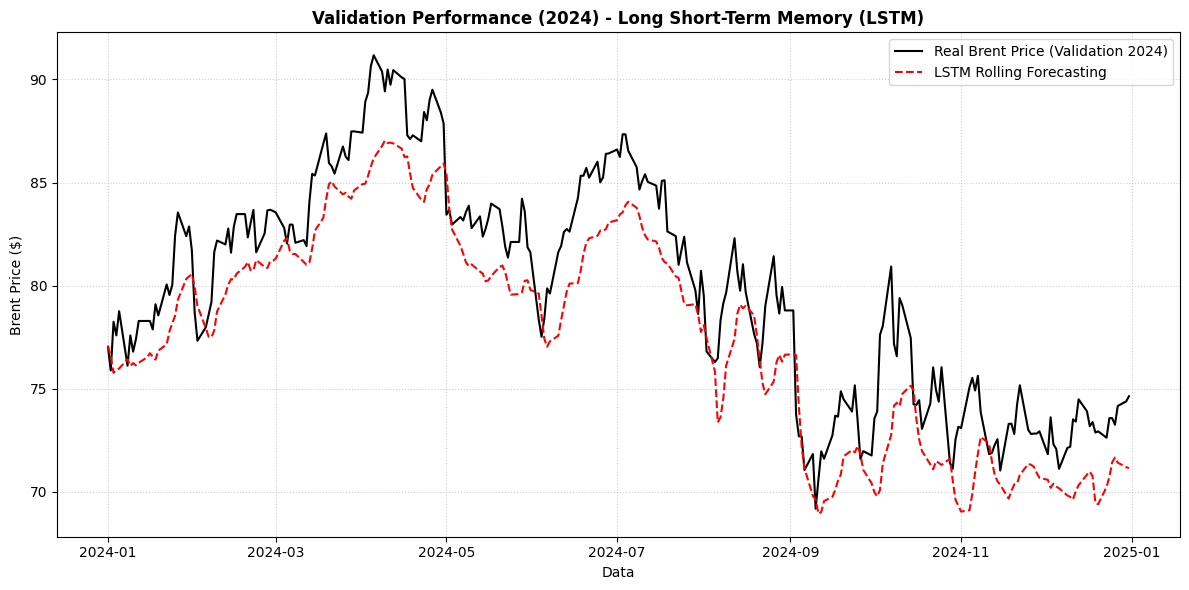

In [ ]:
print("Iniciando a simulação do mercado diário para o ano de Validação (2024) com LSTM...")

#Criamos uma cópia da matriz de validação 3D do pré-processamento para manipulação dinâmica
X_val_dinamico_lstm= np.copy(X_val_lstm)
rolling_predictions_scaled_lstm= []

#Identifica automaticamente o número de features (colunas) usando o DataFrame original
num_features= train_df.shape[1]
tempo_inicio_val_lstm= time.time()

#Garante que o modelo está em modo de avaliação (desativa o dropout)
lstm_modelo_otimizado.eval()

with torch.no_grad():
    for time_point in range(len(y_val)):
        #1. Captura a janela 3D atual e adiciona a dimensão de lote (batch) exigida pelo PyTorch
        janela_atual= torch.tensor(X_val_dinamico_lstm[time_point], dtype=torch.float32).unsqueeze(0).to(device)

        #Faz a predição para o dia atual
        predicao_atual_scaled= lstm_modelo_otimizado(janela_atual).cpu().item()
        rolling_predictions_scaled_lstm.append(predicao_atual_scaled)

        #2. ADAPTAÇÃO DINÂMICA COMPLETA (Walk-Forward Multivariado)
        #Se ainda houver um amanhã dentro do laço de validação, atualizamos todas as features da linha seguinte
        if time_point + 1 < len(y_val):
            #A linha do dia seguinte recebe o bloco 3D inteiro de variáveis reais registradas (incluindo o Brent e as macroeconômicas)
            X_val_dinamico_lstm[time_point + 1]= X_val_lstm[time_point + 1]

tempo_fim_val_lstm= time.time()
tempo_total_val_lstm= tempo_fim_val_lstm - tempo_inicio_val_lstm
tempo_medio_diario_lstm= tempo_total_val_lstm / len(y_val)

#Transforma a lista de resultados em um vetor estruturado do NumPy
rolling_predictions_scaled_lstm= np.array(rolling_predictions_scaled_lstm)

#INVERSÃO DA NORMALIZAÇÃO (Retorno para a escala real em dólares)
#Reconstrói a matriz dummy para as predições da LSTM
dummy_pred_lstm= np.zeros((len(rolling_predictions_scaled_lstm), num_features))
dummy_pred_lstm[:, 0]= rolling_predictions_scaled_lstm
y_pred_dollars_lstm= scaler.inverse_transform(dummy_pred_lstm)[:, 0]

#Reconstrói a matriz dummy para os valores reais de validação
dummy_val= np.zeros((len(y_val), num_features))
dummy_val[:, 0]= y_val
y_val_dollars= scaler.inverse_transform(dummy_val)[:, 0]

mae_lstm= mean_absolute_error(y_val_dollars, y_pred_dollars_lstm)
rmse_lstm= np.sqrt(mean_squared_error(y_val_dollars, y_pred_dollars_lstm))
mape_lstm= mean_absolute_percentage_error(y_val_dollars, y_pred_dollars_lstm) * 100
print("\n============== RESULTADOS LONG SHORT-TERM MEMORY (VALIDAÇÃO OTIMIZADA 2024) ================")
print(f"MAE (2024): ${mae_lstm:.2f}")
print(f"RMSE (2024): ${rmse_lstm:.2f}")
print(f"MAPE (2024): {mape_lstm:.2f}%")
print(f"-------------------------------------------------------------------------")
print(f"Tempo Total de Validação: {tempo_total_val_lstm:.4f} segundos")
print(f"Tempo Médio por Predição Diária: {tempo_medio_diario_lstm:.6f} segundos ({len(y_val)} dias úteis)")

#PLOTAGEM DO GRÁFICO DA VALIDAÇÃO
datas_validacao= val_df.index

plt.figure(figsize=(12, 6))
plt.plot(datas_validacao, y_val_dollars, label="Real Brent Price (Validation 2024)", color="black", linewidth=1.5)
plt.plot(datas_validacao, y_pred_dollars_lstm, label="LSTM Rolling Forecasting", color="red", linestyle="--", linewidth=1.5)
plt.title("Validation Performance (2024) - Long Short-Term Memory (LSTM)", fontsize=12, fontweight="bold")
plt.xlabel("Data")
plt.ylabel("Brent Price ($)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## LSTM - Segunda Versão

In [ ]:
# ============================================================
# LSTM - SEGUNDA VERSÃO
# ============================================================

import os
import random
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

print("\n" + "="*70)
print("LSTM - ABLATION STUDY + TUNING MULTI-SEMENTE")
print("="*70)

UNITS_LIST = [16, 32, 64]
WINDOW_LIST = [10, 20, 30]
SEEDS = [42, 7, 123]

DROPOUT = 0.1
LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS = 200
PATIENCE = 15

FEATURE_SETS_LSTM = {
    "Brent Only": [train_df.columns.get_loc("Brent_Oil")],
    "All Features": list(range(train_scaled.shape[1]))
}

num_features = train_df.shape[1]


def set_all_seeds(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def select_features_lstm(X, feature_idx):
    return X[:, :, feature_idx]


def inverse_target_lstm(y_scaled):
    y_scaled = np.array(y_scaled).reshape(-1)
    dummy = np.zeros((len(y_scaled), num_features))
    dummy[:, 0] = y_scaled
    return scaler.inverse_transform(dummy)[:, 0]


def build_lstm_model(window_size, n_features, units=32, dropout=0.1, learning_rate=0.001):
    model = Sequential([
        Input(shape=(window_size, n_features)),
        LSTM(units),
        Dropout(dropout),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="mse"
    )

    return model


def train_eval_lstm(
    X_train_3d,
    y_train_data,
    X_val_3d,
    y_val_data,
    units,
    dropout,
    learning_rate,
    batch_size,
    epochs,
    patience,
    seed
):
    set_all_seeds(seed)

    window_size = X_train_3d.shape[1]
    n_features_lstm = X_train_3d.shape[2]

    model = build_lstm_model(
        window_size=window_size,
        n_features=n_features_lstm,
        units=units,
        dropout=dropout,
        learning_rate=learning_rate
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )

    t0 = time.time()

    history = model.fit(
        X_train_3d,
        y_train_data,
        validation_data=(X_val_3d, y_val_data),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        shuffle=False,
        verbose=0
    )

    train_time = time.time() - t0
    n_epochs = len(history.history["loss"])

    y_train_pred_scaled = model.predict(X_train_3d, verbose=0).reshape(-1)
    y_val_pred_scaled = model.predict(X_val_3d, verbose=0).reshape(-1)

    y_train_real = inverse_target_lstm(y_train_data)
    y_train_pred = inverse_target_lstm(y_train_pred_scaled)

    y_val_real = inverse_target_lstm(y_val_data)
    y_val_pred = inverse_target_lstm(y_val_pred_scaled)

    return {
        "model": model,
        "history": history.history,
        "seed": seed,
        "units": units,
        "window": window_size,
        "n_epochs": n_epochs,
        "train_time": train_time,
        "MAE_train": mean_absolute_error(y_train_real, y_train_pred),
        "RMSE_train": np.sqrt(mean_squared_error(y_train_real, y_train_pred)),
        "MAPE_train": mean_absolute_percentage_error(y_train_real, y_train_pred) * 100,
        "MAE_val": mean_absolute_error(y_val_real, y_val_pred),
        "RMSE_val": np.sqrt(mean_squared_error(y_val_real, y_val_pred)),
        "MAPE_val": mean_absolute_percentage_error(y_val_real, y_val_pred) * 100,
        "y_val_real": y_val_real,
        "y_val_pred": y_val_pred
    }


LSTM - ABLATION STUDY + TUNING MULTI-SEMENTE


## LSTM - Segunda Versão (Tuning)

In [ ]:
# ============================================================
# TUNING LSTM - FEATURE SETS x WINDOWS x UNITS x SEEDS
# ============================================================

resultados_lstm = []

for feature_name, feature_idx in FEATURE_SETS_LSTM.items():

    print("\n" + "="*70)
    print(f"FEATURE SET: {feature_name}")
    print("="*70)

    for window in WINDOW_LIST:

        print("\n" + "#"*70)
        print(f"WINDOW = {window}")
        print("#"*70)

        val_extended_w = np.vstack([train_scaled[-window:], val_scaled])

        X_train_w, y_train_w = create_sliding_windows(train_scaled, window)
        X_val_w, y_val_w = create_sliding_windows(val_extended_w, window)

        X_train_w = select_features_lstm(X_train_w, feature_idx)
        X_val_w = select_features_lstm(X_val_w, feature_idx)

        for units in UNITS_LIST:

            maes = []
            rmses = []
            mapes = []
            gaps = []
            epochs_used = []
            times = []

            print(f"\n--- Feature={feature_name} | window={window} | units={units} ---")

            for seed in SEEDS:

                resultado = train_eval_lstm(
                    X_train_3d=X_train_w,
                    y_train_data=y_train_w,
                    X_val_3d=X_val_w,
                    y_val_data=y_val_w,
                    units=units,
                    dropout=DROPOUT,
                    learning_rate=LEARNING_RATE,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    patience=PATIENCE,
                    seed=seed
                )

                gap_mae = resultado["MAE_val"] - resultado["MAE_train"]

                maes.append(resultado["MAE_val"])
                rmses.append(resultado["RMSE_val"])
                mapes.append(resultado["MAPE_val"])
                gaps.append(gap_mae)
                epochs_used.append(resultado["n_epochs"])
                times.append(resultado["train_time"])

                print(
                    f"seed={seed} | "
                    f"MAE={resultado['MAE_val']:.4f} | "
                    f"RMSE={resultado['RMSE_val']:.4f} | "
                    f"MAPE={resultado['MAPE_val']:.4f}% | "
                    f"gap={gap_mae:.4f} | "
                    f"epochs={resultado['n_epochs']}"
                )

            resultados_lstm.append({
                "Feature_Set": feature_name,
                "window": window,
                "units": units,
                "MAE_mean": np.mean(maes),
                "MAE_std": np.std(maes),
                "RMSE_mean": np.mean(rmses),
                "MAPE_mean": np.mean(mapes),
                "gap_MAE_mean": np.mean(gaps),
                "epochs_mean": np.mean(epochs_used),
                "time_mean_s": np.mean(times)
            })

df_lstm_tuning = (
    pd.DataFrame(resultados_lstm)
    .sort_values("MAE_mean")
    .reset_index(drop=True)
)

print("\n================ RANKING LSTM - VALIDAÇÃO 2024 ================")
print(df_lstm_tuning.round(4).to_string(index=False))

best_lstm = df_lstm_tuning.iloc[0]

best_feature_set = best_lstm["Feature_Set"]
best_units = int(best_lstm["units"])
best_window = int(best_lstm["window"])

print("\n================ MELHOR CONFIGURAÇÃO LSTM ================")
print(f"Feature Set: {best_feature_set}")
print(f"Window:      {best_window}")
print(f"Units:       {best_units}")
print(f"MAE médio:   {best_lstm['MAE_mean']:.4f} +/- {best_lstm['MAE_std']:.4f}")
print(f"RMSE médio:  {best_lstm['RMSE_mean']:.4f}")
print(f"MAPE médio:  {best_lstm['MAPE_mean']:.4f}%")


FEATURE SET: Brent Only

######################################################################
WINDOW = 10
######################################################################

--- Feature=Brent Only | window=10 | units=16 ---
seed=42 | MAE=1.7505 | RMSE=2.2156 | MAPE=2.2056% | gap=-0.6068 | epochs=24
seed=7 | MAE=1.6510 | RMSE=2.0661 | MAPE=2.0663% | gap=-0.4732 | epochs=20
seed=123 | MAE=1.5724 | RMSE=2.0076 | MAPE=1.9904% | gap=-0.9328 | epochs=18

--- Feature=Brent Only | window=10 | units=32 ---
seed=42 | MAE=1.9607 | RMSE=2.4354 | MAPE=2.4579% | gap=-0.7997 | epochs=20
seed=7 | MAE=1.7322 | RMSE=2.1561 | MAPE=2.1616% | gap=-1.0964 | epochs=18
seed=123 | MAE=1.7447 | RMSE=2.2060 | MAPE=2.1972% | gap=-0.7856 | epochs=19

--- Feature=Brent Only | window=10 | units=64 ---
seed=42 | MAE=2.2044 | RMSE=2.6547 | MAPE=2.7261% | gap=-0.7341 | epochs=17
seed=7 | MAE=2.1789 | RMSE=2.6383 | MAPE=2.6910% | gap=-0.8707 | epochs=16
seed=123 | MAE=2.0067 | RMSE=2.4376 | MAPE=2.4952% | gap=-0.

## LSTM - Teste


LSTM FINAL - TESTE 2025

Treinando LSTM final | seed=42
MAE Teste:  $0.9767
RMSE Teste: $1.3243
MAPE Teste: 1.4451%

Treinando LSTM final | seed=7
MAE Teste:  $1.7114
RMSE Teste: $2.3217
MAPE Teste: 2.5029%

Treinando LSTM final | seed=123
MAE Teste:  $1.0304
RMSE Teste: $1.3790
MAPE Teste: 1.5310%

================ RESULTADOS LSTM TESTE 2025 ================
 seed  MAE_test  RMSE_test  MAPE_test  n_epochs  train_time_s
   42    0.9767     1.3243     1.4451       200      148.2531
    7    1.7114     2.3217     2.5029        19       15.7086
  123    1.0304     1.3790     1.5310       173      134.5389

Resumo:
Feature Set:      Brent Only
Window:           20
Units:            16
MAE médio teste:  $1.2395 +/- 0.4096
RMSE médio teste: $1.6750
MAPE médio teste: 1.8263%


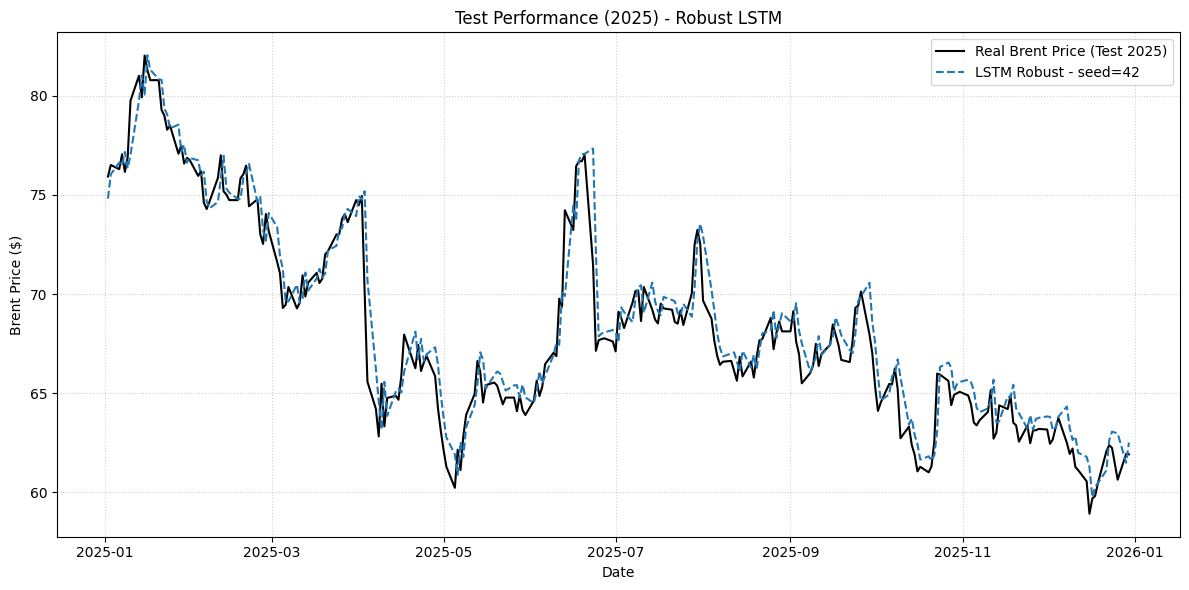

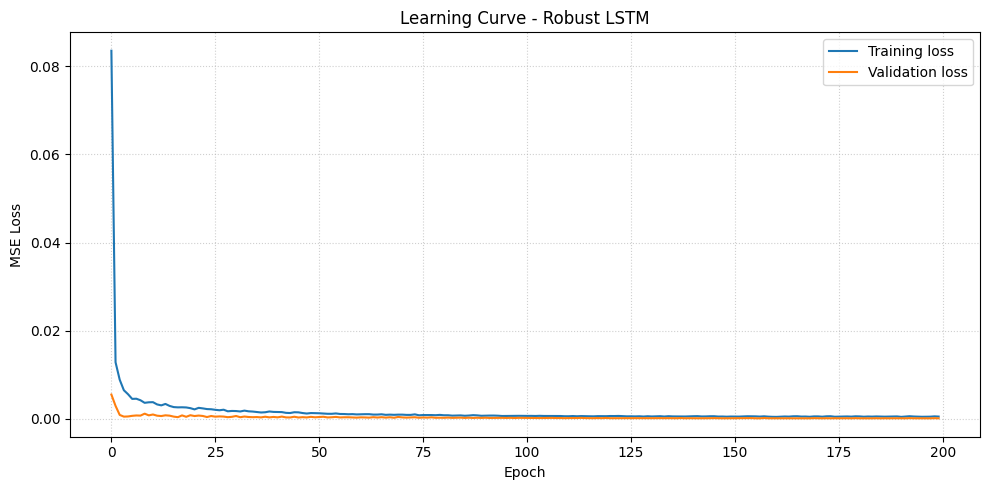

In [ ]:
# ============================================================
# LSTM FINAL - TESTE 2025 COM A MELHOR CONFIGURAÇÃO
# ============================================================

print("\n" + "="*70)
print("LSTM FINAL - TESTE 2025")
print("="*70)

if best_feature_set == "Brent Only":
    feature_idx_final = FEATURE_SETS_LSTM["Brent Only"]
else:
    feature_idx_final = FEATURE_SETS_LSTM["All Features"]

window = best_window

val_extended_final = np.vstack([train_scaled[-window:], val_scaled])
test_extended_final = np.vstack([val_scaled[-window:], test_scaled])

X_train_final, y_train_final = create_sliding_windows(train_scaled, window)
X_val_final, y_val_final = create_sliding_windows(val_extended_final, window)
X_test_final, y_test_final = create_sliding_windows(test_extended_final, window)

X_train_final = select_features_lstm(X_train_final, feature_idx_final)
X_val_final = select_features_lstm(X_val_final, feature_idx_final)
X_test_final = select_features_lstm(X_test_final, feature_idx_final)

resultados_teste_lstm = []

for seed in SEEDS:

    print(f"\nTreinando LSTM final | seed={seed}")

    resultado = train_eval_lstm(
        X_train_3d=X_train_final,
        y_train_data=y_train_final,
        X_val_3d=X_val_final,
        y_val_data=y_val_final,
        units=best_units,
        dropout=DROPOUT,
        learning_rate=LEARNING_RATE,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        patience=PATIENCE,
        seed=seed
    )

    model = resultado["model"]

    y_test_pred_scaled = model.predict(X_test_final, verbose=0).reshape(-1)

    y_test_pred = inverse_target_lstm(y_test_pred_scaled)
    y_test_real = inverse_target_lstm(y_test_final)

    mae_test = mean_absolute_error(y_test_real, y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test_real, y_test_pred))
    mape_test = mean_absolute_percentage_error(y_test_real, y_test_pred) * 100

    resultados_teste_lstm.append({
        "seed": seed,
        "MAE_test": mae_test,
        "RMSE_test": rmse_test,
        "MAPE_test": mape_test,
        "n_epochs": resultado["n_epochs"],
        "train_time_s": resultado["train_time"],
        "y_test_real": y_test_real,
        "y_test_pred": y_test_pred,
        "history": resultado["history"]
    })

    print(f"MAE Teste:  ${mae_test:.4f}")
    print(f"RMSE Teste: ${rmse_test:.4f}")
    print(f"MAPE Teste: {mape_test:.4f}%")

df_lstm_test = pd.DataFrame([
    {
        "seed": r["seed"],
        "MAE_test": r["MAE_test"],
        "RMSE_test": r["RMSE_test"],
        "MAPE_test": r["MAPE_test"],
        "n_epochs": r["n_epochs"],
        "train_time_s": r["train_time_s"]
    }
    for r in resultados_teste_lstm
])

print("\n================ RESULTADOS LSTM TESTE 2025 ================")
print(df_lstm_test.round(4).to_string(index=False))

print("\nResumo:")
print(f"Feature Set:      {best_feature_set}")
print(f"Window:           {best_window}")
print(f"Units:            {best_units}")
print(f"MAE médio teste:  ${df_lstm_test['MAE_test'].mean():.4f} +/- {df_lstm_test['MAE_test'].std():.4f}")
print(f"RMSE médio teste: ${df_lstm_test['RMSE_test'].mean():.4f}")
print(f"MAPE médio teste: {df_lstm_test['MAPE_test'].mean():.4f}%")

best_seed_idx = df_lstm_test["MAE_test"].idxmin()
best_result = resultados_teste_lstm[best_seed_idx]

plt.figure(figsize=(12, 6))
plt.plot(test_df.index, best_result["y_test_real"], label="Real Brent Price (Test 2025)", color="black", linewidth=1.5)
plt.plot(test_df.index, best_result["y_test_pred"], label=f"LSTM Robust - seed={best_result['seed']}", linestyle="--", linewidth=1.5)
plt.title("Test Performance (2025) - Robust LSTM")
plt.xlabel("Date")
plt.ylabel("Brent Price ($)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(best_result["history"]["loss"], label="Training loss")
plt.plot(best_result["history"]["val_loss"], label="Validation loss")
plt.title("Learning Curve - Robust LSTM")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

#Test Results

##SVR Test

Iniciando a simulação do mercado diário para o ano de Teste (2025) com SVR...

================ RESULTADOS SUPPORT VECTOR REGRESSION ================
MAE (2025): $1.4358
RMSE (2025): $1.8563
MAPE (2025): 2.1403%
Tempo Total de Teste: 0.0976 segundos
Tempo Médio por Predição Diária: 0.000380 segundos (257 dias úteis)


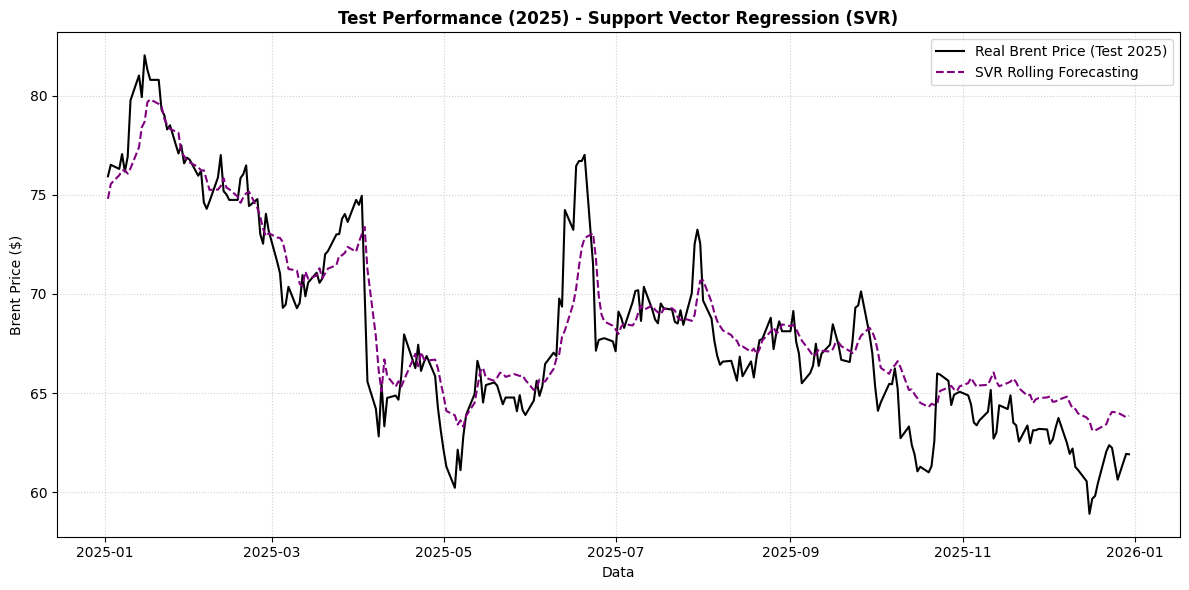

In [ ]:
print("Iniciando a simulação do mercado diário para o ano de Teste (2025) com SVR...")

#O modelo entra em 2025 conhecendo toda a história até 31/12/2024
X_historico_svr= np.vstack((X_train_rf, X_val_rf))
y_historico_svr= np.concatenate((y_train, y_val))

#Ajustamos o modelo uma única vez com o histórico unificado antes de iniciar o teste
svr_modelo_otimizado.fit(X_historico_svr, y_historico_svr)

#Cria uma cópia da matriz de teste para atualizar os lags dinamicamente
X_test_dinamico_svr= np.copy(X_test_rf)
rolling_predictions_scaled_svr= []

#Identifica automaticamente o número de features (colunas) usando o DataFrame original
num_features= train_df.shape[1]
tempo_inicio_test_svr= time.time()

for time_point in range(len(y_test)):
    #1. Faz a predição para o dia atual com base no histórico recente
    janela_atual= X_test_dinamico_svr[time_point].reshape(1, -1)
    predicao_atual_scaled= svr_modelo_otimizado.predict(janela_atual)[0]
    rolling_predictions_scaled_svr.append(predicao_atual_scaled)

    #2. Adaptação temporal das features defasadas para a linha de amanhã
    if time_point + 1 < len(y_test):
        X_test_dinamico_svr[time_point + 1]= X_test_rf[time_point + 1]

tempo_fim_test_svr= time.time()
tempo_total_test_svr= tempo_fim_test_svr - tempo_inicio_test_svr
tempo_medio_diario_svr= tempo_total_test_svr / len(y_test)

#Transforma a lista de resultados em um vetor estruturado do NumPy
rolling_predictions_scaled_svr= np.array(rolling_predictions_scaled_svr)

#Inversão da normalização (retorno para a escala real em dólares)
dummy_pred_svr= np.zeros((len(rolling_predictions_scaled_svr), num_features))
dummy_pred_svr[:, 0]= rolling_predictions_scaled_svr
y_pred_dollars_svr= scaler.inverse_transform(dummy_pred_svr)[:, 0]

#Reconstrói a matriz dummy para os valores reais de teste
dummy_test= np.zeros((len(y_test), num_features))
dummy_test[:, 0]= y_test
y_test_dollars= scaler.inverse_transform(dummy_test)[:, 0]

mae_svr= mean_absolute_error(y_test_dollars, y_pred_dollars_svr)
rmse_svr= np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars_svr))
mape_svr= mean_absolute_percentage_error(y_test_dollars, y_pred_dollars_svr) * 100

print("\n================ RESULTADOS SUPPORT VECTOR REGRESSION ================")
print(f"MAE (2025): ${mae_svr:.4f}")
print(f"RMSE (2025): ${rmse_svr:.4f}")
print(f"MAPE (2025): {mape_svr:.4f}%")
print(f"Tempo Total de Teste: {tempo_total_test_svr:.4f} segundos")
print(f"Tempo Médio por Predição Diária: {tempo_medio_diario_svr:.6f} segundos ({len(y_test)} dias úteis)")

#PLOTAGEM DO GRÁFICO DO TESTE
datas_teste= test_df.index
plt.figure(figsize=(12, 6))
plt.plot(datas_teste, y_test_dollars, label="Real Brent Price (Test 2025)", color="black", linewidth=1.5)
plt.plot(datas_teste, y_pred_dollars_svr, label="SVR Rolling Forecasting", color="purple", linestyle="--", linewidth=1.5)
plt.title("Test Performance (2025) - Support Vector Regression (SVR)", fontsize=12, fontweight="bold")
plt.xlabel("Data")
plt.ylabel("Brent Price ($)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

#Teste Estatístico

In [ ]:
"""#Teste Estatístico"""

# ============================================================
# TESTE ESTATÍSTICO - DIEBOLD-MARIANO COM CORREÇÃO HLN
# ============================================================

from scipy import stats

print("\n" + "="*70)
print("TESTE ESTATÍSTICO DIEBOLD-MARIANO - TESTE 2025")
print("="*70)

def dm_test_hln(y_true, pred_a, pred_b, loss="abs", h=1):
    y_true, pred_a, pred_b = pd.concat(
        [y_true, pred_a, pred_b],
        axis=1,
        join="inner"
    ).dropna().T.values

    err_a = y_true - pred_a
    err_b = y_true - pred_b

    if loss == "abs":
        d = np.abs(err_a) - np.abs(err_b)
    elif loss == "sq":
        d = err_a**2 - err_b**2
    else:
        raise ValueError("loss deve ser 'abs' ou 'sq'.")

    n = len(d)
    mean_d = np.mean(d)

    gamma0 = np.var(d, ddof=0)
    var_d = gamma0

    for lag in range(1, h):
        gamma = np.cov(d[lag:], d[:-lag], ddof=0)[0, 1]
        var_d += 2 * gamma

    denom = np.sqrt(var_d / n)

    if denom == 0 or np.isclose(denom, 0):
        return 0.0, 1.0, mean_d, n

    dm = mean_d / denom

    hln_factor = np.sqrt((n + 1 - 2*h + h*(h-1)/n) / n)
    dm_hln = dm * hln_factor

    p_value = 2 * stats.t.cdf(-np.abs(dm_hln), df=n-1)

    return dm_hln, p_value, mean_d, n

# ============================================================
# ORGANIZA AS PREVISÕES DO TESTE 2025
# Cada série é ancorada pela CAUDA do índice de 2025, usando seu
# próprio comprimento. Assim não dependemos de supor quantos dias
# de janela cada modelo perdeu — o alinhamento é automático.
# ============================================================

pred_dict = {}

full_index = test_df.index  # 257 dias de 2025

def alinhar(valores, nome):
    """Cria uma Série ancorada nos ÚLTIMOS len(valores) dias de 2025."""
    valores = np.asarray(valores).reshape(-1)
    n = len(valores)
    idx = full_index[-n:]              # pega a cauda do tamanho certo
    return pd.Series(valores, index=idx, name=nome)

# --- Série real (ano inteiro de 2025) ---
y_true_test_series = pd.Series(brent_test, index=test_brent.index, name="Real")

# --- Baselines: cobrem o ano todo (257) ---
pred_dict["Naive"] = alinhar(naive_pred_test, "Naive")

if "prediction_arima_dynamic" in globals():
    pred_dict["ARIMA Rolling"] = prediction_arima_rolling.copy()

if "prediction_arima_static" in globals():
    pred_dict["ARIMA Static"] = prediction_arima_static.copy()

# --- Modelos de ML (o alinhar() descobre o comprimento sozinho) ---
if "ridge_brent" in globals():
    pred_dict["Ridge Brent"] = alinhar(ridge_brent[1], "Ridge Brent")

if "ridge_all" in globals():
    pred_dict["Ridge All"] = alinhar(ridge_all[1], "Ridge All")

if "y_pred_dollars_rf_test" in globals():
    pred_dict["Random Forest"] = alinhar(
        y_pred_dollars_rf_test,
        "Random Forest"
    )

if "y_pred_dollars_svr" in globals():
    pred_dict["SVR"] = alinhar(y_pred_dollars_svr, "SVR")

if "best_result" in globals():
    pred_dict["LSTM Robust"] = alinhar(best_result["y_test_pred"], "LSTM Robust")


# ============================================================
# DIAGNÓSTICO DE ALINHAMENTO (confira antes de confiar nos p-valores)
# ============================================================

print("\n--- Comprimento de cada série de predição ---")
for nome, serie in pred_dict.items():
    print(f"{nome:15s}: {len(serie)} dias")

# Interseção de datas comum a TODOS os modelos (é o que o DM vai usar)
indices_comuns = y_true_test_series.index
for serie in pred_dict.values():
    indices_comuns = indices_comuns.intersection(serie.index)

print(f"\nDias comuns a todos os modelos (base do DM): {len(indices_comuns)}")
print(f"Primeiro dia comparado: {indices_comuns.min().date()}")
print(f"Último dia comparado:   {indices_comuns.max().date()}")

print("\nModelos incluídos no teste DM:")
print(list(pred_dict.keys()))


# ============================================================
# MATRIZ DE P-VALORES TODOS CONTRA TODOS
# ============================================================

model_names = list(pred_dict.keys())

dm_pvalues = pd.DataFrame(
    np.eye(len(model_names)),
    index=model_names,
    columns=model_names
)

dm_direction = pd.DataFrame(
    "",
    index=model_names,
    columns=model_names
)

for i, model_a in enumerate(model_names):
    for j, model_b in enumerate(model_names):
        if j <= i:
            continue

        dm_stat, p_value, mean_diff, n = dm_test_hln(
            y_true_test_series,
            pred_dict[model_a],
            pred_dict[model_b],
            loss="abs",
            h=1
        )

        dm_pvalues.loc[model_a, model_b] = p_value
        dm_pvalues.loc[model_b, model_a] = p_value

        if p_value < 0.05:
            melhor = model_b if mean_diff > 0 else model_a
            texto = f"{melhor} melhor"
        else:
            texto = "sem diferença"

        dm_direction.loc[model_a, model_b] = texto
        dm_direction.loc[model_b, model_a] = texto


print("\n================ MATRIZ DE P-VALORES DM-HLN ================")
print(dm_pvalues.round(4).to_string())

print("\n================ INTERPRETAÇÃO ================")
print(dm_direction.to_string())


# ============================================================
# COMPARAÇÃO CONTRA BASELINE NAIVE
# (mean_loss_diff > 0  =>  o modelo erra menos que o Naive)
# ============================================================

baseline = "Naive"
rows = []

for model_name in model_names:
    if model_name == baseline:
        continue

    dm_stat, p_value, mean_diff, n = dm_test_hln(
        y_true_test_series,
        pred_dict[baseline],
        pred_dict[model_name],
        loss="abs",
        h=1
    )

    if p_value < 0.05:
        verdict = "modelo melhor" if mean_diff > 0 else "Naive melhor"
    else:
        verdict = "empate estatístico"

    rows.append({
        "Modelo": model_name,
        "DM_stat": dm_stat,
        "p_value": p_value,
        "mean_loss_diff": mean_diff,
        "n": n,
        "veredito_vs_Naive": verdict
    })

dm_vs_naive = pd.DataFrame(rows)

print("\n================ DM-HLN CONTRA NAIVE ================")
print(dm_vs_naive.round(4).to_string(index=False))


TESTE ESTATÍSTICO DIEBOLD-MARIANO - TESTE 2025

--- Comprimento de cada série de predição ---
Naive          : 257 dias
ARIMA Static   : 257 dias
Ridge Brent    : 257 dias
Ridge All      : 257 dias
Random Forest  : 257 dias
SVR            : 257 dias
LSTM Robust    : 257 dias

Dias comuns a todos os modelos (base do DM): 257
Primeiro dia comparado: 2025-01-02
Último dia comparado:   2025-12-30

Modelos incluídos no teste DM:
['Naive', 'ARIMA Static', 'Ridge Brent', 'Ridge All', 'Random Forest', 'SVR', 'LSTM Robust']

================ MATRIZ DE P-VALORES DM-HLN ================
                Naive  ARIMA Static  Ridge Brent  Ridge All  Random Forest  SVR  LSTM Robust
Naive          1.0000           0.0       0.0000     0.0001         0.0072  0.0       0.0027
ARIMA Static   0.0000           1.0       0.0000     0.0000         0.0000  0.0       0.0000
Ridge Brent    0.0000           0.0       1.0000     0.7902         0.0048  0.0       0.0228
Ridge All      0.0001           0.0       0.

#Plot Comparativo


GERANDO FIGURA FINAL - TESTE 2025
Atenção: SVR de teste não encontrado. SVR não será plotado.
Atenção: LSTM de teste não encontrada. LSTM não será plotada.

Séries incluídas na figura:
['Real', 'Naive', 'Random Forest']
Dias plotados: 257
Período: 2025-01-02 até 2025-12-30


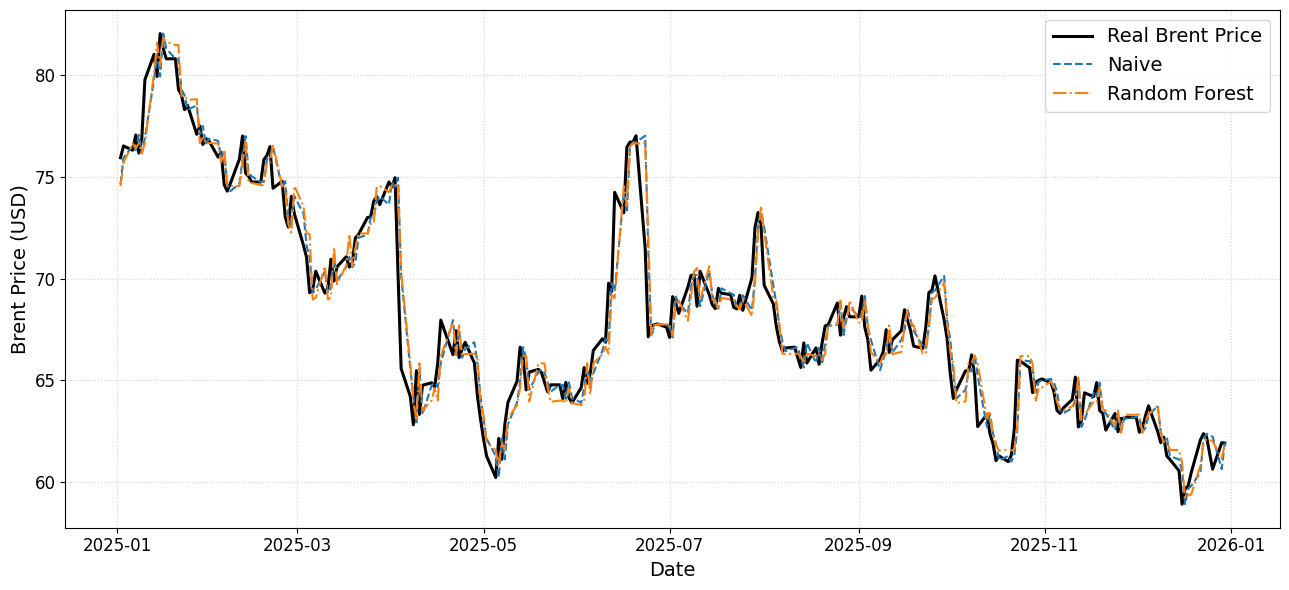

In [ ]:
# ============================================================
# FIGURA FINAL DO ARTIGO - REAL vs MODELOS SELECIONADOS
# ============================================================

print("\n" + "="*70)
print("GERANDO FIGURA FINAL - TESTE 2025")
print("="*70)

full_index = test_df.index

def alinhar_predicao(valores, nome):
    valores = np.asarray(valores).reshape(-1)
    idx = full_index[-len(valores):]
    return pd.Series(valores, index=idx, name=nome)

# Série real
real_series = pd.Series(brent_test, index=test_brent.index, name="Real")

# Naive
naive_series = alinhar_predicao(naive_pred_test, "Naive")

# Random Forest final
rf_series = alinhar_predicao(y_pred_dollars_rf_test, "Random Forest")

# SVR — use apenas se for previsão de TESTE 2025
if "y_pred_dollars_svr_test" in globals():
    svr_series = alinhar_predicao(y_pred_dollars_svr_test, "SVR")
elif "svr_pred_test_series" in globals():
    svr_series = svr_pred_test_series.rename("SVR")
else:
    svr_series = None
    print("Atenção: SVR de teste não encontrado. SVR não será plotado.")

# LSTM robusta
if "best_result" in globals() and "y_test_pred" in best_result:
    lstm_series = alinhar_predicao(best_result["y_test_pred"], "LSTM")
elif "lstm_pred_test_series" in globals():
    lstm_series = lstm_pred_test_series.rename("LSTM")
else:
    lstm_series = None
    print("Atenção: LSTM de teste não encontrada. LSTM não será plotada.")

# Monta DataFrame final
series_to_plot = [
    real_series,
    naive_series,
    rf_series,
]

if svr_series is not None:
    series_to_plot.append(svr_series)

if lstm_series is not None:
    series_to_plot.append(lstm_series)

plot_df = pd.concat(series_to_plot, axis=1, join="inner").dropna()

print("\nSéries incluídas na figura:")
print(plot_df.columns.tolist())
print(f"Dias plotados: {len(plot_df)}")
print(f"Período: {plot_df.index.min().date()} até {plot_df.index.max().date()}")

plt.figure(figsize=(13, 6))

plt.plot(
    plot_df.index,
    plot_df["Real"],
    label="Real Brent Price",
    color="black",
    linewidth=2.2
)

plt.plot(
    plot_df.index,
    plot_df["Naive"],
    label="Naive",
    linestyle="--",
    linewidth=1.5
)

plt.plot(
    plot_df.index,
    plot_df["Random Forest"],
    label="Random Forest",
    linestyle="-.",
    linewidth=1.5
)

# if "SVR" in plot_df.columns:
#     plt.plot(
#         plot_df.index,
#         plot_df["SVR"],
#         label="SVR",
#         linestyle=":",
#         linewidth=1.8
#     )

# if "LSTM" in plot_df.columns:
#     plt.plot(
#         plot_df.index,
#         plot_df["LSTM"],
#         label="LSTM",
#         linestyle="--",
#         linewidth=1.5
#     )

#plt.title("Brent Crude Oil Price Forecasts on the 2025 Test Set",
#          fontsize=13, fontweight="bold")
plt.xlabel("Date", fontsize=14)
plt.ylabel("Brent Price (USD)", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle=":", alpha=0.55)
plt.legend(fontsize=14)
plt.tight_layout()

plt.savefig("fig_forecast_comparison_2025.png", dpi=300, bbox_inches="tight")
plt.savefig("fig_forecast_comparison_2025.pdf", bbox_inches="tight")
plt.show()

#Tools Versions

In [ ]:
!cat /proc/cpuinfo | grep 'model name' | uniq

!cat /proc/meminfo | grep MemTotal

import torch, sklearn, pandas
print(torch.__version__, sklearn.__version__, pandas.__version__)

!python --version

model name	: Intel(R) Xeon(R) CPU @ 2.20GHz
MemTotal:       13286944 kB
2.11.0+cpu 1.6.1 2.2.2
Python 3.12.13
